# 08 -- Confidence Intervals & Statistical Significance

Quantifying the patterns from notebook 07 (bias_initial).
Each section feeds one or more of the three research questions.

| # | Question |
|---|----------|
| **Q1** | *Disparity* -- do spell-checkers recognise European-origin names at systematically higher rates? |
| **Q2** | *Mechanism* -- how much of the gap is script-level vs lexical within a shared writing system? |
| **Q3** | *Correction skew* -- do suggestions for flagged names favour European-origin alternatives? |

**Conditions analysed**

| Condition | Column | Notes |
|-----------|--------|-------|
| Hunspell B |  | Latin transliteration |
| SymSpell B |  | Latin transliteration |
| LT-auto A |  | Original script; LanguageTool uses language detection |
| LT-auto B |  | Latin transliteration |

Hunspell A and SymSpell A return 0% for all non-Latin scripts -- excluded (see next cell).


In [282]:
import json
import sqlite3
import unicodedata
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import (
    proportion_confint,
    proportions_ztest,
    proportion_effectsize,
)
from statsmodels.stats.contingency_tables import mcnemar as _mcnemar
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf

pd.set_option('display.max_rows', 80)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Libraries loaded.')

Libraries loaded.


In [283]:
# ── Load from SQLite ──────────────────────────────────────────────────────────
con = sqlite3.connect('../data/full_results2.db')
df_raw = pd.read_sql('SELECT * FROM names', con)
con.close()
print(f'Raw rows loaded: {len(df_raw):,}')

# ── Cleaning (replicates notebook 07 (bias_initial) filter) ──────────────────────────────────
# Keep single-word names made up of Unicode letters, combining marks,
# hyphens, and apostrophes only. This removes digits, punctuation noise,
# and multi-word entries that would confound the per-name comparisons.
_EXTRA = {'-', "'"}

def _valid(name):
    if not isinstance(name, str) or ' ' in name or len(name) < 2:
        return False
    return all(
        unicodedata.category(ch)[0] in ('L', 'M') or ch in _EXTRA
        for ch in name
    )

df = df_raw[df_raw['name'].apply(_valid)].copy()
df['name_length'] = df['name'].str.len()

# Short ethnicolr labels: 'GreaterEuropean,WestEuropean,French' -> 'French'
df['eth_short'] = df['ethnicolr_race'].str.split(',').str[-1].fillna('Unknown')

print(f'After cleaning: {len(df):,} names ({len(df)/len(df_raw)*100:.1f}% retained)')
print(f'\nScript families (top 12):')
print(df['name_script'].value_counts().head(12).to_string())
print(f'\nOverall Condition B name recognition rates:')
for col, label in [('hunspell_latin_known','Hunspell'),
                   ('symspell_latin_known','SymSpell'),
                   ('lt_auto_latin_known', 'LT-auto ')]:
    print(f'  {label}: {df[col].mean()*100:.2f}%')

Raw rows loaded: 727,352
After cleaning: 571,028 names (78.5% retained)

Script families (top 12):
name_script
Latin         463454
Arabic         32247
Cyrillic       26636
CJK            20290
Hangul         12324
Hebrew          4198
Greek           3243
Bengali         2824
Georgian        2098
Ethiopic         671
Hiragana         647
Devanagari       598

Overall Condition B name recognition rates:
  Hunspell: 4.90%
  SymSpell: 4.16%
  LT-auto : 13.28%


In [284]:
# ── Shared constants ──────────────────────────────────────────────────────────────

# All four meaningful conditions
FOCUS_CONDS = [
    ('hunspell_latin_known', 'Hunspell B'),
    ('symspell_latin_known', 'SymSpell B'),
    ('lt_auto_orig_known',   'LT-auto A'),
    ('lt_auto_latin_known',  'LT-auto B'),
]

# Condition-B only -- used for ethnicolr analyses where LT-auto A is redundant
# (for Latin-script names anyascii changes nothing, so A == B)
COND_B = [
    ('hunspell_latin_known', 'Hunspell B'),
    ('symspell_latin_known', 'SymSpell B'),
    ('lt_auto_latin_known',  'LT-auto B'),
]

# LT-auto columns used explicitly in the McNemar (paired) analysis
LT_ORIG_COL  = 'lt_auto_orig_known'
LT_LATIN_COL = 'lt_auto_latin_known'

# Script families with >= 500 names (smaller groups give unreliable estimates)
MAJOR_SCRIPTS = [
    'Latin', 'Arabic', 'Cyrillic', 'CJK', 'Hangul',
    'Hebrew', 'Bengali', 'Greek', 'Georgian', 'Ethiopic',
]

# Ethnicolr categories considered European-origin
EUROPEAN_ETH = {'British', 'Germanic', 'Nordic', 'French', 'Italian', 'EastEuropean'}

# Derived subsets
df_major      = df[df['name_script'].isin(MAJOR_SCRIPTS)].copy()
df_non_latin  = df[df['name_script'] != 'Latin'].copy()
df_latin_only = df[df['name_script'] == 'Latin'].copy()

# European-origin subset
df_european_eth = df[df['ethnicolr_race'].str.split(',').str[-1].isin(EUROPEAN_ETH)].copy()

print(f'Major-script subset:   {len(df_major):,} names')
print(f'Non-Latin subset:      {len(df_non_latin):,} names')
print(f'Latin-only subset:     {len(df_latin_only):,} names')
print(f'European-origin subset: {len(df_european_eth):,} names')


Major-script subset:   567,985 names
Non-Latin subset:      107,574 names
Latin-only subset:     463,454 names
European-origin subset: 213,188 names


In [285]:
# ── Why Hunspell A and SymSpell A are excluded ─────────────────────────────────
# Hunspell and SymSpell match names against an English word-list stored in
# ASCII / Latin-1.  They cannot parse non-Latin Unicode characters at all.
# Their Condition A (original-script) recognition rate is therefore 0 % for
# every non-Latin script family -- not a finding, just a hard technical limit.
# We confirm this here and exclude both conditions from all subsequent tests.

print('Condition A recognition -- non-Latin-script names (major script families only)')
print('Hunspell and SymSpell cannot process non-Latin characters.\n')

for col, label in [('hunspell_orig_known', 'Hunspell A'),
                    ('symspell_orig_known', 'SymSpell A')]:
    sub = df_non_latin[df_non_latin['name_script'].isin(MAJOR_SCRIPTS)]
    tbl = sub.groupby('name_script')[col].agg(['sum', 'count'])
    tbl['rate_%'] = (tbl['sum'] / tbl['count'] * 100).round(2)
    tbl.columns   = ['n_known', 'n_total', 'rate_%']
    print(f'--- {label} ---')
    print(tbl[['n_total', 'n_known', 'rate_%']].to_string())
    print()

print('Both tools return 0 % for every non-Latin script.')
print('Hunspell A and SymSpell A are excluded from all further analysis.')


Condition A recognition -- non-Latin-script names (major script families only)
Hunspell and SymSpell cannot process non-Latin characters.

--- Hunspell A ---
             n_total  n_known  rate_%
name_script                          
Arabic         32247        0  0.0000
Bengali         2824        0  0.0000
CJK            20290        0  0.0000
Cyrillic       26636        0  0.0000
Ethiopic         671        0  0.0000
Georgian        2098        0  0.0000
Greek           3243        0  0.0000
Hangul         12324        0  0.0000
Hebrew          4198        0  0.0000

--- SymSpell A ---
             n_total  n_known  rate_%
name_script                          
Arabic         32247        0  0.0000
Bengali         2824        0  0.0000
CJK            20290        0  0.0000
Cyrillic       26636        0  0.0000
Ethiopic         671        0  0.0000
Georgian        2098        0  0.0000
Greek           3243        0  0.0000
Hangul         12324        0  0.0000
Hebrew          4198    

---
## Note: statistics at this sample size

~570,000 names means every p-value is effectively zero -- a 0.01 pp difference is
"significant". Significance tests confirm gaps are real; they say nothing about size.

Use this order of priority when writing up:
1. **Cohen's h / Odds Ratio** -- magnitude of the gap, scale-independent
2. **Confidence intervals** -- precision of each rate estimate
3. **p-values** -- mention briefly to confirm not noise

Patterns consistent across Hunspell, SymSpell, and LT-auto are the strongest evidence
of a systemic issue rather than one tool's quirk.


---
## Q1: Disparity -- Wilson Confidence Intervals

95% Wilson CIs give a precise range for each group's true recognition rate.
At this sample size the intervals are very narrow -- the rates are well-estimated.
What matters is the *gap between groups*, not the width of any single interval.

**Script analysis** (all four conditions): how much does script family alone predict recognition?

**Origin analysis** (Condition B, Latin-script names only): once all names are romanised,
any remaining gap between e.g. British and EastAsian names is lexical, not script-related.


In [286]:
def recognition_table(data, group_col, known_col, min_n=100):
    """
    For each group: n, n recognised, recognition %, 95% Wilson CI.
    Groups with < min_n names are excluded.
    Returns a DataFrame sorted by recognition rate descending.
    """
    rows = []
    for group, grp in data.groupby(group_col):
        n = len(grp)
        if n < min_n:
            continue
        k = int(grp[known_col].sum())
        lo, hi = proportion_confint(k, n, alpha=0.05, method='wilson')
        rows.append({
            'group':    group,
            'n':        n,
            'known':    k,
            'rate_%':   round(k / n * 100, 2),
            'CI_low':   round(lo * 100, 2),
            'CI_high':  round(hi * 100, 2),
            'CI_width': round((hi - lo) * 100, 3),
        })
    return (
        pd.DataFrame(rows)
        .sort_values('rate_%', ascending=False)
        .reset_index(drop=True)
    )


# Per-script CIs for all four meaningful conditions
print('Q1: Recognition rates by script family')
print('95% Wilson confidence intervals\n')

for col, label in FOCUS_CONDS:
    tbl = recognition_table(df_major, 'name_script', col)
    print(f'-- {label} --')
    print(tbl.to_string(index=False))
    print()


Q1: Recognition rates by script family
95% Wilson confidence intervals

-- Hunspell B --
   group      n  known  rate_%  CI_low  CI_high  CI_width
   Greek   3243    408 12.5800 11.4800  13.7700    2.2830
Cyrillic  26636   1473  5.5300  5.2600   5.8100    0.5490
   Latin 463454  25189  5.4400  5.3700   5.5000    0.1310
Georgian   2098    112  5.3400  4.4600   6.3800    1.9290
 Bengali   2824    149  5.2800  4.5100   6.1600    1.6520
Ethiopic    671     16  2.3800  1.4700   3.8400    2.3650
  Arabic  32247    423  1.3100  1.1900   1.4400    0.2490
  Hebrew   4198     26  0.6200  0.4200   0.9100    0.4830
  Hangul  12324      3  0.0200  0.0100   0.0700    0.0630
     CJK  20290      0  0.0000  0.0000   0.0200    0.0190

-- SymSpell B --
   group      n  known  rate_%  CI_low  CI_high  CI_width
   Greek   3243    394 12.1500 11.0700  13.3200    2.2490
Georgian   2098    197  9.3900  8.2100  10.7100    2.4980
 Bengali   2824    192  6.8000  5.9300   7.7900    1.8590
Cyrillic  26636   1360 

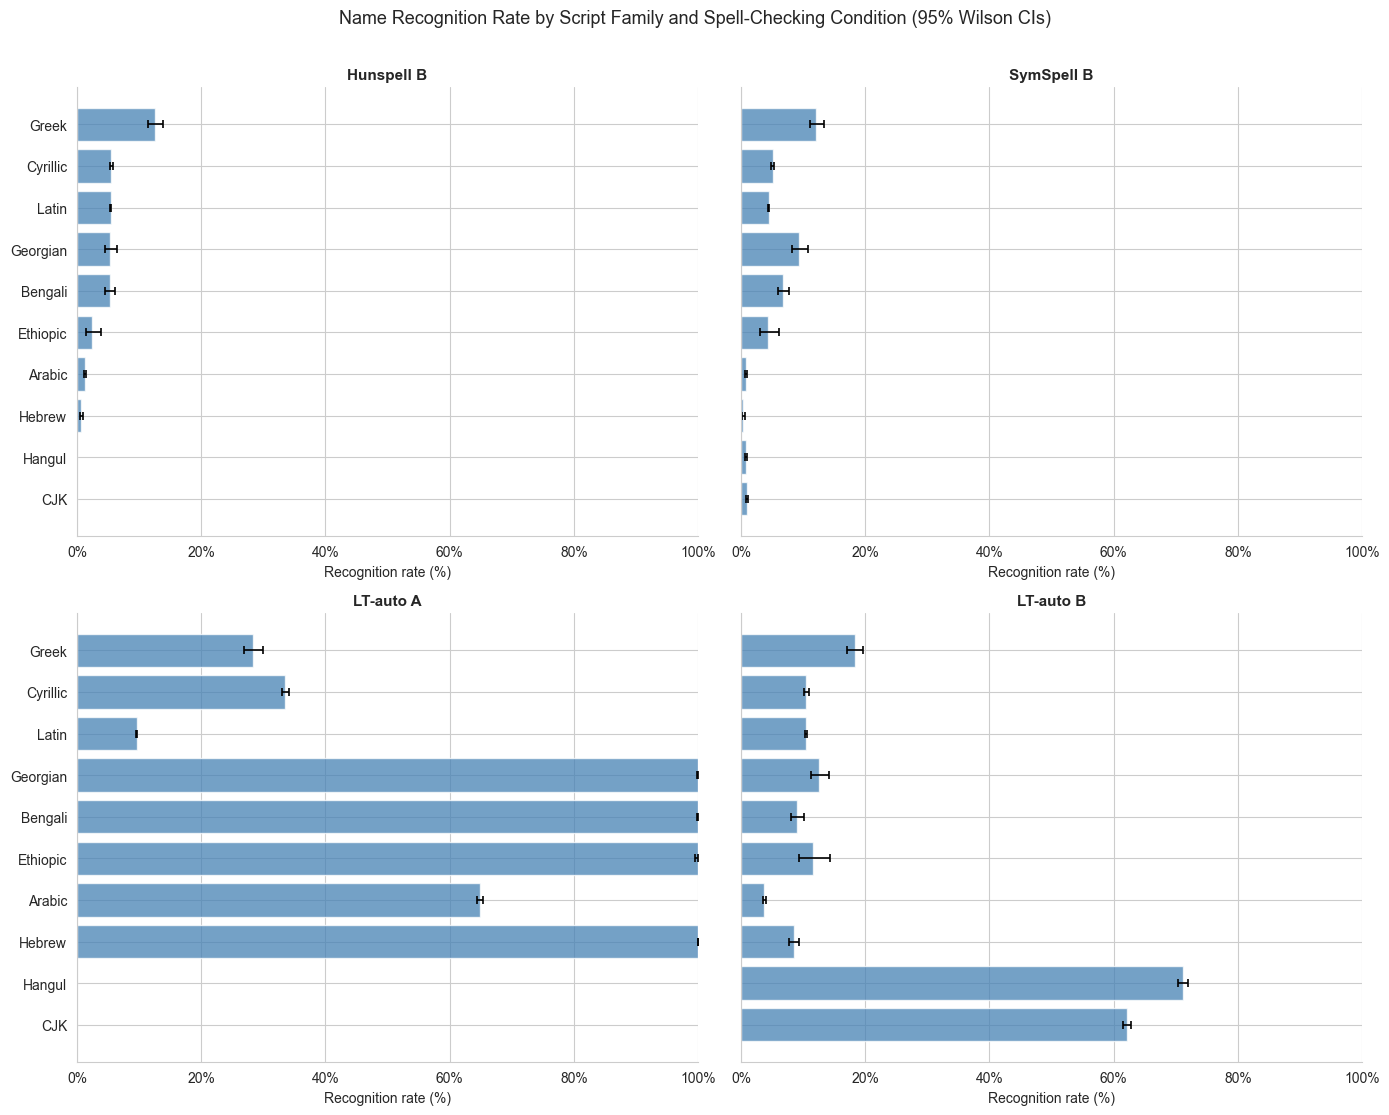

Consistent patterns = systemic property of English spell-checkers.
Tool-specific outliers (e.g. Arabic/Hebrew under LT-auto A) reflect design differences.


In [287]:
# Q1: Recognition rates by script -- all four conditions in a 2x2 grid
# Same y-axis order across panels so patterns are easy to compare.

ref_order = (
    recognition_table(df_major, "name_script", "hunspell_latin_known")
    .sort_values("rate_%", ascending=True)["group"].tolist()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharey=True)
axes = axes.flatten()

for ax, (col, label) in zip(axes, FOCUS_CONDS):
    ci_tbl = recognition_table(df_major, "name_script", col)
    ci_tbl = ci_tbl.set_index("group").reindex(ref_order).reset_index()
    ax.barh(
        ci_tbl["group"], ci_tbl["rate_%"],
        xerr=[ci_tbl["rate_%"] - ci_tbl["CI_low"],
              ci_tbl["CI_high"] - ci_tbl["rate_%"]],
        color="steelblue", alpha=0.75, capsize=3,
        error_kw={"elinewidth": 1.2, "capthick": 1.2},
    )
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Recognition rate (%)")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_xlim(0, 100)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

fig.suptitle(
    "Name Recognition Rate by Script Family and Spell-Checking Condition (95% Wilson CIs)"
    "",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

print("Consistent patterns = systemic property of English spell-checkers.")
print("Tool-specific outliers (e.g. Arabic/Hebrew under LT-auto A) reflect design differences.")


Q1: Recognition rates by predicted origin category -- Condition B
LATIN-SCRIPT NAMES ONLY | 95% Wilson confidence intervals

-- Hunspell B --
             group     n  known  rate_%  CI_low  CI_high  CI_width
          Africans 23263    251  1.0800  0.9500   1.2200    0.2660
IndianSubContinent 66404   1604  2.4200  2.3000   2.5400    0.2340
            Jewish 17342    533  3.0700  2.8300   3.3400    0.5140
          Japanese 25996    814  3.1300  2.9300   3.3500    0.4240
            Muslim 37143   1245  3.3500  3.1700   3.5400    0.3660
          Hispanic 15970    883  5.5300  5.1900   5.8900    0.7090
      EastEuropean 13443    787  5.8500  5.4700   6.2600    0.7940
           Italian 18584   1132  6.0900  5.7600   6.4400    0.6880
         EastAsian 96972   6075  6.2600  6.1100   6.4200    0.3050
            Nordic 49333   3701  7.5000  7.2700   7.7400    0.4650
           British 82959   6681  8.0500  7.8700   8.2400    0.3700
          Germanic 10255    889  8.6700  8.1400   9.23

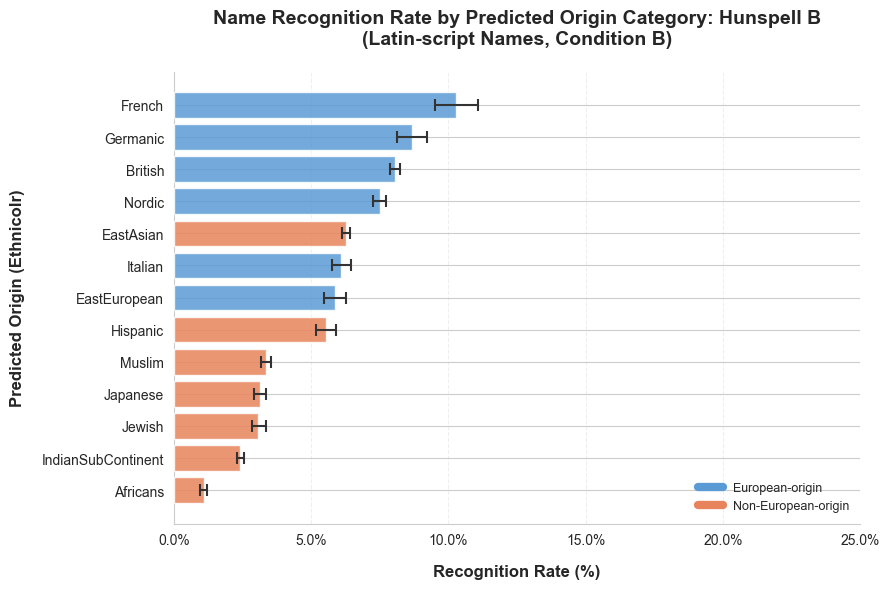

-- SymSpell B --
             group     n  known  rate_%  CI_low  CI_high  CI_width
          Africans 23263    207  0.8900  0.7800   1.0200    0.2420
IndianSubContinent 66404   1421  2.1400  2.0300   2.2500    0.2200
            Jewish 17342    454  2.6200  2.3900   2.8700    0.4760
          Japanese 25996    689  2.6500  2.4600   2.8500    0.3910
            Muslim 37143   1035  2.7900  2.6200   2.9600    0.3350
          Hispanic 15970    740  4.6300  4.3200   4.9700    0.6520
      EastEuropean 13443    625  4.6500  4.3100   5.0200    0.7120
           Italian 18584    959  5.1600  4.8500   5.4900    0.6360
         EastAsian 96972   5126  5.2900  5.1500   5.4300    0.2820
            Nordic 49333   3116  6.3200  6.1000   6.5300    0.4290
           British 82959   5575  6.7200  6.5500   6.8900    0.3410
          Germanic 10255    512  4.9900  4.5900   5.4300    0.8440
            French  5790    262  4.5300  4.0200   5.0900    1.0720
------------------------------
File Saved: Q1

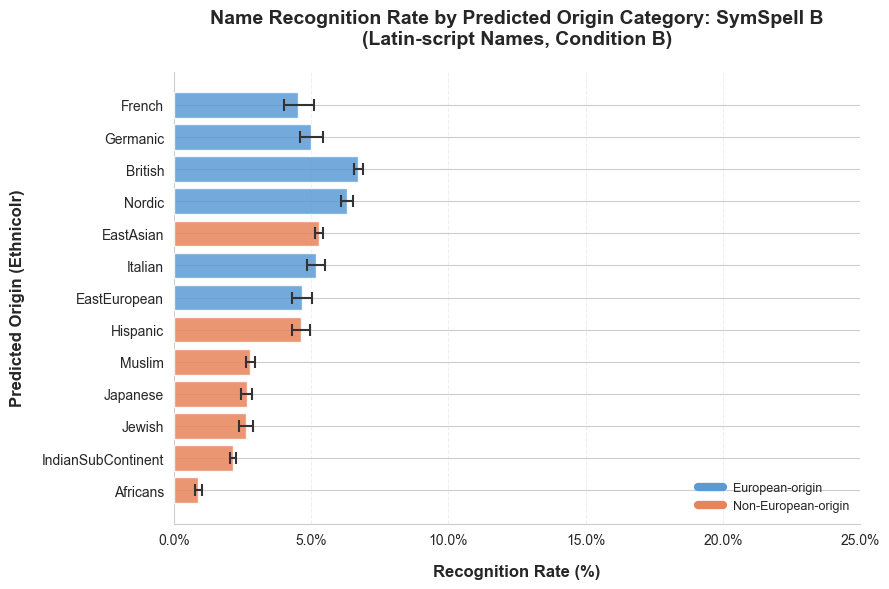

-- LT-auto B --
             group     n  known  rate_%  CI_low  CI_high  CI_width
          Africans 23263    745  3.2000  2.9800   3.4400    0.4530
IndianSubContinent 66404   3948  5.9500  5.7700   6.1300    0.3600
            Jewish 17342   1535  8.8500  8.4400   9.2800    0.8460
          Japanese 25996   2073  7.9700  7.6500   8.3100    0.6590
            Muslim 37143   2463  6.6300  6.3800   6.8900    0.5060
          Hispanic 15970   2600 16.2800 15.7200  16.8600    1.1450
      EastEuropean 13443   1819 13.5300 12.9600  14.1200    1.1560
           Italian 18584   3281 17.6500 17.1100  18.2100    1.0960
         EastAsian 96972   9760 10.0600  9.8800  10.2600    0.3790
            Nordic 49333   8133 16.4900 16.1600  16.8200    0.6550
           British 82959   9307 11.2200 11.0100  11.4400    0.4300
          Germanic 10255   2012 19.6200 18.8600  20.4000    1.5370
            French  5790    849 14.6600 13.7800  15.6000    1.8220
------------------------------
File Saved: Q1_

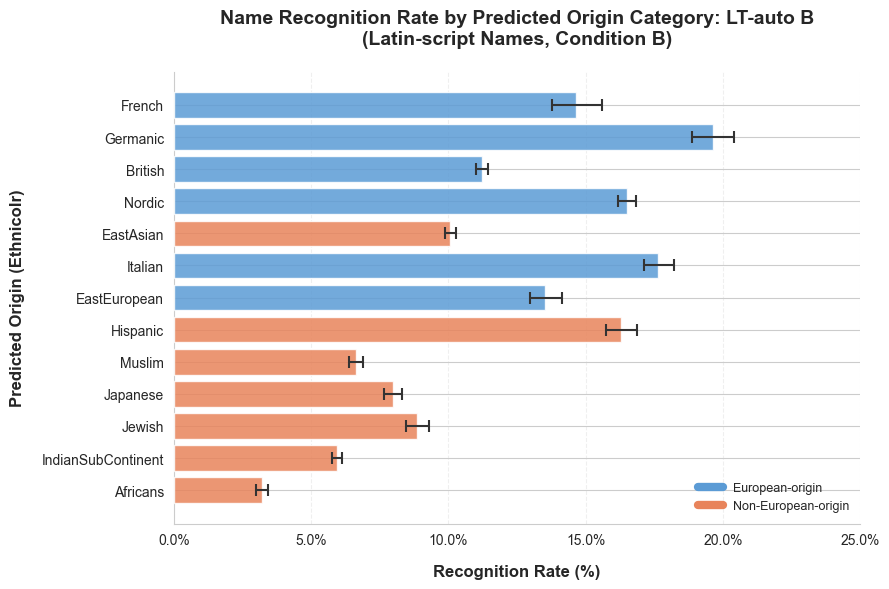

In [288]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from matplotlib.lines import Line2D

# 1. Filter Data (Latin names only to isolate lexical bias)
eth_data_plot = df_latin_only[df_latin_only["eth_short"] != "Unknown"]

# 2. Establish Global Y-Axis Order 
# (Ensures all 3 plots are visually comparable in your thesis)
ref_eth_order = (
    recognition_table(eth_data_plot, "eth_short", "hunspell_latin_known")
    .sort_values("rate_%", ascending=True)["group"].tolist()
)

print("Q1: Recognition rates by predicted origin category -- Condition B")
print("LATIN-SCRIPT NAMES ONLY | 95% Wilson confidence intervals\n")

# 3. Iterate through tools to print data and save individual plots
for col, label in COND_B:
    # --- Calculation Logic ---
    tbl = (
        recognition_table(eth_data_plot, "eth_short", col)
        .set_index("group")
        .reindex(ref_eth_order)
        .reset_index()
    )
    
    # Print table to console for record-keeping
    print(f"-- {label} --")
    print(tbl.to_string(index=False))
    print("-" * 30)

    # --- Plotting Logic (Standalone Figure per Tool) ---
    fig, ax = plt.subplots(figsize=(9, max(6, len(ref_eth_order) * 0.45)))
    
    # Matching the 'coral/steelblue' logic from your working script
    colors = ["#5B9BD5" if g in EUROPEAN_ETH else "#E8845B" for g in tbl["group"]]
    
    # Generate Horizontal Bar Chart
    ax.barh(
        tbl["group"], tbl["rate_%"],
        xerr=[tbl["rate_%"] - tbl["CI_low"], 
              tbl["CI_high"] - tbl["rate_%"]],
        color=colors, alpha=0.85, capsize=4,
        error_kw={"elinewidth": 1.5, "capthick": 1.5, "ecolor": "#333333"},
        zorder=3
    )

    # --- Thesis-Grade Formatting ---
    ax.set_title(f"Name Recognition Rate by Predicted Origin Category: {label}\n(Latin-script Names, Condition B)", 
                 fontsize=14, fontweight="bold", pad=20)
    
    ax.set_xlabel("Recognition Rate (%)", fontsize=12, fontweight="bold", labelpad=12)
    ax.set_ylabel("Predicted Origin (Ethnicolr)", fontsize=12, fontweight="bold", labelpad=12)
    
    # Enforce consistent scale (0-25%) across all tool exports
    ax.set_xlim(0, 25)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    
    # Clean up visual noise
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)

    # Legend to explain origin grouping
    custom_lines = [Line2D([0], [0], color='#5B9BD5', lw=6),
                    Line2D([0], [0], color='#E8845B', lw=6)]
    ax.legend(custom_lines, ['European-origin', 'Non-European-origin'], 
              loc='lower right', frameon=False, fontsize=9)

    plt.tight_layout()
    
    # 4. Save High-Res Artifact
    safe_label = label.replace(' ', '_').replace('(', '').replace(')', '')
    filename = f"Q1_recognition_{safe_label}.png"
    
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"File Saved: {filename}\n")
    
    plt.show()
    plt.close(fig)

---
## Q2: Mechanism -- McNemar's Test (LT-auto A vs B only)

Each name was tested twice: original script (A) and Latin transliteration (B).
McNemar's test checks whether the A-to-B shift is systematic:
- **b** = recognised in A but not B
- **c** = recognised in B but not A

If c >> b, transliteration fixed a script barrier.

**Why LT-auto only:** Hunspell/SymSpell return 0% for all non-Latin scripts in A,
forcing b = 0 by construction -- the result would be trivially one-sided.
LT-auto has genuine discordant pairs (Arabic, Hebrew partially recognised in A via
language detection; CJK/Hangul near-zero in A).

Comparing the per-script delta_pp values answers Q2 directly: large delta = script was
the barrier; small delta = something else (detection or dictionary) already helped in A.


In [289]:
def mcnemar_result(data, orig_col, lat_col):
    """
    McNemar's test comparing Condition A vs Condition B (paired binary outcomes).

    2x2 layout:
               | B known | B unknown
    A known    |  both   |  a_only (b)
    A unknown  |  b_only (c) | neither

    Null hypothesis: b == c (no systematic shift).
    c >> b means transliteration helps recognition.
    """
    a = data[orig_col].astype(bool)
    b = data[lat_col].astype(bool)

    both   = int(( a &  b).sum())
    a_only = int(( a & ~b).sum())  # b in the formula
    b_only = int((~a &  b).sum())  # c in the formula
    neith  = int((~a & ~b).sum())

    result = _mcnemar([[both, a_only], [b_only, neith]], exact=False, correction=True)

    return {
        'n':           len(data),
        'rate_A_%':    round(a.mean() * 100, 2),
        'rate_B_%':    round(b.mean() * 100, 2),
        'delta_pp':    round((b.mean() - a.mean()) * 100, 2),
        'b (A-only)':  a_only,
        'c (B-only)':  b_only,
        'chi2':        round(result.statistic, 2),
        'p':           result.pvalue,
    }


print("Q2: McNemar's test -- LT-auto, Condition A vs Condition B")
print('Non-Latin-script names only')
print('(Hunspell/SymSpell A = 0 % for all non-Latin scripts -- excluded)')
print('=' * 70)

rows = []
r = mcnemar_result(df_non_latin, LT_ORIG_COL, LT_LATIN_COL)
r['scope'] = 'ALL non-Latin'
rows.append(r)

for script in [s for s in MAJOR_SCRIPTS if s != 'Latin']:
    sub = df_non_latin[df_non_latin['name_script'] == script]
    if len(sub) < 100:
        continue
    r = mcnemar_result(sub, LT_ORIG_COL, LT_LATIN_COL)
    r['scope'] = script
    rows.append(r)

tbl = pd.DataFrame(rows)[[
    'scope', 'n', 'rate_A_%', 'rate_B_%', 'delta_pp',
    'b (A-only)', 'c (B-only)', 'chi2', 'p'
]]
tbl['p'] = tbl['p'].apply(lambda v: f'{v:.2e}')

print()
print(tbl.to_string(index=False))

print()
print('Interpretation:')
print('  c >> b  : transliteration fixed a script barrier (e.g. CJK, Hangul)')
print('  b ~= c  : some Condition A recognition exists (e.g. Arabic via language detection)')
print('  delta_pp: practical magnitude; p confirms the shift is not chance.')


Q2: McNemar's test -- LT-auto, Condition A vs Condition B
Non-Latin-script names only
(Hunspell/SymSpell A = 0 % for all non-Latin scripts -- excluded)

        scope      n  rate_A_%  rate_B_%  delta_pp  b (A-only)  c (B-only)       chi2         p
ALL non-Latin 107574   39.3200   25.3700  -13.9500       38383       23378  3645.0200  0.00e+00
       Arabic  32247   64.8900    3.7300  -61.1600       20018         297 19142.4300  0.00e+00
     Cyrillic  26636   33.5600   10.5000  -23.0600        7272        1130  4488.4400  0.00e+00
          CJK  20290    0.0000   62.1600   62.1600           0       12612 12610.0000  0.00e+00
       Hangul  12324    0.0000   71.1100   71.1100           0        8764  8762.0000  0.00e+00
       Hebrew   4198  100.0000    8.5000  -91.5000        3841           0  3839.0000  0.00e+00
      Bengali   2824  100.0000    9.0700  -90.9300        2568           0  2566.0000  0.00e+00
        Greek   3243   28.3400   18.2900  -10.0500         747         421    9

---
## Q1 (continued): Chi-squared and Pairwise Comparisons

**Chi-squared** tests whether recognition is independent of group membership across all groups.
**Pairwise z-tests** compare each group to a reference (Latin for scripts; British for origins).
Benjamini-Hochberg FDR correction is applied. At this n, essentially all comparisons
will be significant -- focus on effect sizes in the next section.


In [290]:
print('Q1: Chi-squared test of independence')
print('H0: recognition rate is independent of group membership')
print()

eth_sub = df_latin_only[df_latin_only['eth_short'] != 'Unknown']

print('By script family (all four conditions):')
for col, label in FOCUS_CONDS:
    ct = pd.crosstab(df_major['name_script'], df_major[col].astype(int))
    chi2, p, dof, _ = chi2_contingency(ct)
    print(f'  {label:<14}  chi2({dof}) = {chi2:>12,.1f},  p = {p:.2e}')

print()
print('By origin category -- Condition B, Latin-script names only:')
for col, label in COND_B:
    ct2 = pd.crosstab(eth_sub['eth_short'], eth_sub[col].astype(int))
    chi2b, pb, dof2, _ = chi2_contingency(ct2)
    print(f'  {label:<14}  chi2({dof2}) = {chi2b:>12,.1f},  p = {pb:.2e}')

print()
print('All p << 0.001: recognition rates are not uniform across groups.')
print('Proceed to pairwise tests to identify which groups drive this.')


Q1: Chi-squared test of independence
H0: recognition rate is independent of group membership

By script family (all four conditions):
  Hunspell B      chi2(9) =      3,462.8,  p = 0.00e+00
  SymSpell B      chi2(9) =      2,821.2,  p = 0.00e+00
  LT-auto A       chi2(9) =    142,258.8,  p = 0.00e+00
  LT-auto B       chi2(9) =     83,971.9,  p = 0.00e+00

By origin category -- Condition B, Latin-script names only:
  Hunspell B      chi2(12) =      4,944.9,  p = 0.00e+00
  SymSpell B      chi2(12) =      3,687.2,  p = 0.00e+00
  LT-auto B       chi2(12) =      8,294.8,  p = 0.00e+00

All p << 0.001: recognition rates are not uniform across groups.
Proceed to pairwise tests to identify which groups drive this.


In [291]:
def pairwise_vs_ref(data, group_col, known_col, ref_group, min_n=100):
    """
    Two-proportion z-test for every group vs ref_group.
    Returns a DataFrame with raw and Benjamini-Hochberg FDR-corrected p-values.
    """
    ref   = data[data[group_col] == ref_group]
    k_ref = int(ref[known_col].sum())
    n_ref = len(ref)
    p_ref = k_ref / n_ref

    rows = []
    for name, grp in data.groupby(group_col):
        if name == ref_group or len(grp) < min_n:
            continue
        k, n = int(grp[known_col].sum()), len(grp)
        z, p_raw = proportions_ztest([k, k_ref], [n, n_ref])
        rows.append({
            'group':   name,
            'n':       n,
            f'{ref_group}_%': round(p_ref * 100, 2),
            'group_%': round(k / n * 100, 2),
            'diff_pp': round((k / n - p_ref) * 100, 2),
            'z':       round(z, 2),
            'p_raw':   p_raw,
        })

    if not rows:
        return pd.DataFrame()

    out = pd.DataFrame(rows)
    _, p_adj, _, _ = multipletests(out['p_raw'], method='fdr_bh')
    out['p_adj (BH)'] = p_adj
    out['sig'] = out['p_adj (BH)'].apply(
        lambda v: '***' if v < 0.001 else ('**' if v < 0.01 else ('*' if v < 0.05 else 'ns'))
    )
    return out.sort_values('diff_pp').reset_index(drop=True)


print('Q1: Pairwise comparisons -- each script vs Latin (reference group)')
print('FDR correction: Benjamini-Hochberg | neg diff_pp = lower than Latin\n')

for col, label in FOCUS_CONDS:
    pw = pairwise_vs_ref(df_major, 'name_script', col, 'Latin')
    pw['p_adj (BH)'] = pw['p_adj (BH)'].apply(lambda v: f'{v:.2e}')
    print(f'-- {label} --')
    print(pw.to_string(index=False))
    print()


Q1: Pairwise comparisons -- each script vs Latin (reference group)
FDR correction: Benjamini-Hochberg | neg diff_pp = lower than Latin

-- Hunspell B --
   group     n  Latin_%  group_%  diff_pp        z  p_raw p_adj (BH) sig
     CJK 20290   5.4400   0.0000  -5.4400 -34.1100 0.0000  5.07e-254 ***
  Hangul 12324   5.4400   0.0200  -5.4100 -26.4700 0.0000  5.83e-154 ***
  Hebrew  4198   5.4400   0.6200  -4.8200 -13.7500 0.0000   8.82e-43 ***
  Arabic 32247   5.4400   1.3100  -4.1200 -32.3400 0.0000  7.61e-229 ***
Ethiopic   671   5.4400   2.3800  -3.0500  -3.4800 0.0005   7.40e-04 ***
 Bengali  2824   5.4400   5.2800  -0.1600  -0.3700 0.7104   7.99e-01  ns
Georgian  2098   5.4400   5.3400  -0.1000  -0.1900 0.8455   8.46e-01  ns
Cyrillic 26636   5.4400   5.5300   0.1000   0.6700 0.5060   6.51e-01  ns
   Greek  3243   5.4400  12.5800   7.1500  17.8100 0.0000   1.31e-70 ***

-- SymSpell B --
   group     n  Latin_%  group_%  diff_pp        z  p_raw p_adj (BH) sig
  Hebrew  4198   4.4700   

In [292]:
# Q1: Pairwise origin comparisons -- Condition B, Latin-script names only
print('Q1: Pairwise comparisons -- each origin category vs British (reference group)')
print('LATIN-SCRIPT NAMES ONLY | Condition B | FDR: Benjamini-Hochberg')
print('neg diff_pp = lower recognition rate than British-origin names\n')

eth_counts = df_latin_only['eth_short'].value_counts()
valid_eth  = eth_counts[eth_counts >= 100].index
eth_data   = df_latin_only[df_latin_only['eth_short'].isin(valid_eth)]

for col, label in COND_B:
    pw = pairwise_vs_ref(eth_data, 'eth_short', col, 'British')
    if not pw.empty:
        pw['p_adj (BH)'] = pw['p_adj (BH)'].apply(lambda v: f'{v:.2e}')
    print(f'-- {label} --')
    print(pw.to_string(index=False))
    print()


Q1: Pairwise comparisons -- each origin category vs British (reference group)
LATIN-SCRIPT NAMES ONLY | Condition B | FDR: Benjamini-Hochberg
neg diff_pp = lower recognition rate than British-origin names

-- Hunspell B --
             group     n  British_%  group_%  diff_pp        z  p_raw p_adj (BH) sig
          Africans 23263     8.0500   1.0800  -6.9700 -38.0600 0.0000   0.00e+00 ***
IndianSubContinent 66404     8.0500   2.4200  -5.6400 -47.3000 0.0000   0.00e+00 ***
            Jewish 17342     8.0500   3.0700  -4.9800 -23.0800 0.0000  1.59e-117 ***
          Japanese 25996     8.0500   3.1300  -4.9200 -27.3600 0.0000  2.41e-164 ***
            Muslim 37143     8.0500   3.3500  -4.7000 -30.3300 0.0000  1.73e-201 ***
          Hispanic 15970     8.0500   5.5300  -2.5200 -10.9900 0.0000   7.08e-28 ***
      EastEuropean 13443     8.0500   5.8500  -2.2000  -8.8500 0.0000   1.19e-18 ***
           Italian 18584     8.0500   6.0900  -1.9600  -9.0700 0.0000   1.75e-19 ***
         Eas

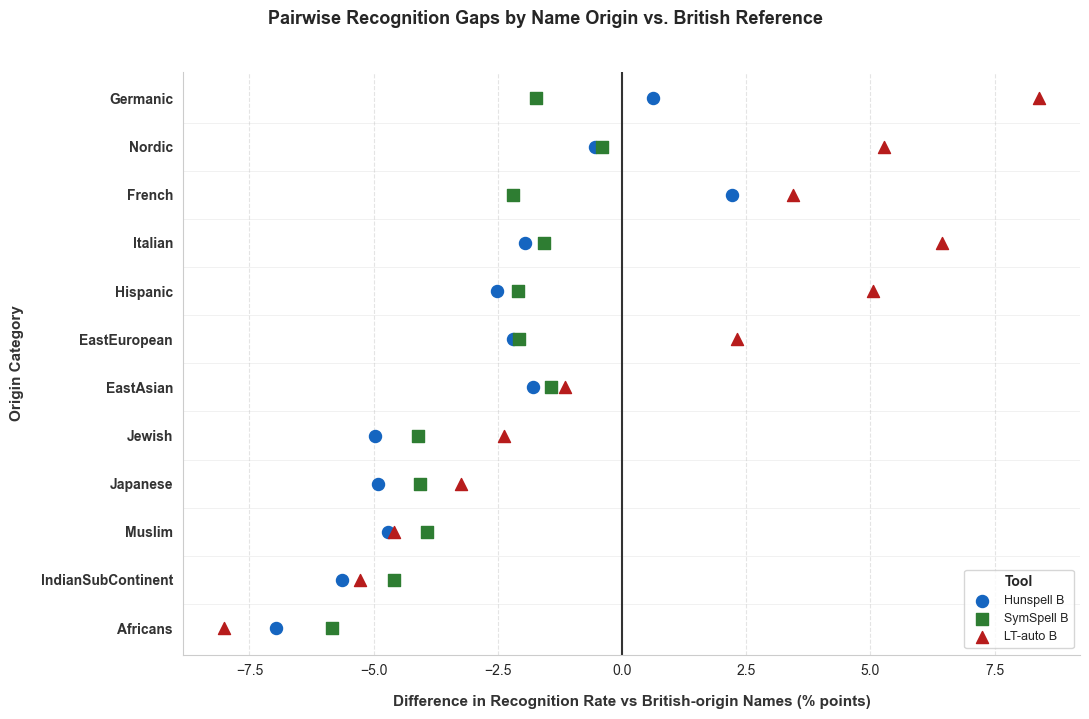

In [293]:
# Pairwise recognition gap vs British -- dot plot with BH-corrected significance
import matplotlib.pyplot as plt
import numpy as np

eth_counts = df_latin_only["eth_short"].value_counts()
valid_eth  = eth_counts[eth_counts >= 100].index
eth_data   = df_latin_only[df_latin_only["eth_short"].isin(valid_eth)]

PAIR_COLOURS = {"Hunspell B": "#1565c0", "SymSpell B": "#2e7d32", "LT-auto B": "#b71c1c"}
PAIR_MARKERS = {"Hunspell B": "o", "SymSpell B": "s", "LT-auto B": "^"}

pw_results = {}
for col, label in COND_B:
    pw = pairwise_vs_ref(eth_data, "eth_short", col, "British")
    pw_results[label] = pw.set_index("group")

# Order groups by mean diff_pp across tools (most penalised at top)
mean_diff = pd.concat(
    [pw_results[l]["diff_pp"].rename(l) for l in pw_results], axis=1
).mean(axis=1)
group_order = mean_diff.sort_values().index.tolist()
y_pos = np.arange(len(group_order))

# Check whether any non-significant results exist across all tools
all_sig = all(
    (pw_results[label]["sig"] != "ns").all()
    for _, label in COND_B
)

fig, ax = plt.subplots(figsize=(11, 7), facecolor="white")
ax.set_facecolor("white")

for i, (col, label) in enumerate(COND_B):
    pw = pw_results[label].reindex(group_order)

    if all_sig:
        # All results significant -- no need to distinguish, plot all filled
        ax.scatter(pw["diff_pp"], y_pos,
                   color=PAIR_COLOURS[label], marker=PAIR_MARKERS[label],
                   s=75, label=label, zorder=3)
    else:
        sig_mask = pw["sig"] != "ns"
        ax.scatter(pw["diff_pp"][sig_mask], y_pos[sig_mask.values],
                   color=PAIR_COLOURS[label], marker=PAIR_MARKERS[label],
                   s=75, label=label, zorder=3)
        ax.scatter(pw["diff_pp"][~sig_mask], y_pos[(~sig_mask).values],
                   facecolors="none", edgecolors=PAIR_COLOURS[label],
                   marker=PAIR_MARKERS[label],
                   s=75, linewidths=1.5, zorder=3)

ax.axvline(0, color="#333333", linewidth=1.5, zorder=2)
for y in range(len(group_order) - 1):
    ax.axhline(y + 0.5, color="#bdbdbd", linestyle="-", linewidth=0.5, alpha=0.3, zorder=0)

ax.set_yticks(y_pos)
ax.set_yticklabels(group_order, fontweight="bold", color="#333333")
ax.set_xlabel("Difference in Recognition Rate vs British-origin Names (% points)", fontweight="bold", fontsize=11, color="#333333", labelpad=12)
ax.set_ylabel("Origin Category", fontweight="bold", fontsize=11, color="#333333", labelpad=12)
ax.grid(True, axis="x", which="major", linestyle="--", alpha=0.4, color="#bdbdbd")
ax.grid(False, axis="y")

subtitle = (
    "Condition B, Latin-script names only | All comparisons significant (BH-corrected p < 0.05)"
    if all_sig else
    "Condition B, Latin-script names only | Filled = significant (BH-corrected p < 0.05), Open = ns"
)
fig.suptitle(
    f"Pairwise Recognition Gaps by Name Origin vs. British Reference",
    fontsize=13, fontweight="bold", y=1.02
)
legend = ax.legend(title="Tool", loc="lower right", fontsize=9, frameon=True)
legend.get_title().set_fontweight("bold")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('pairwise_british_comp.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Q1 (continued): Cohen's h Effect Size

Cohen's h measures effect size for proportions, independent of sample size.

| |h| | Label |
|----|-------|
| < 0.20 | Small |
| 0.20 -- 0.50 | Medium |
| 0.50 -- 0.80 | Large |
| > 0.80 | Very large |

A very large effect means the gap is practically meaningful, not just statistically detectable.


In [294]:
def cohens_h_table(data, group_col, known_col, ref_group, min_n=100):
    """
    Cohen's h for every group vs ref_group.
    Negative h = group has lower recognition than the reference.
    """
    p_ref = data[data[group_col] == ref_group][known_col].mean()
    rows  = []
    for name, grp in data.groupby(group_col):
        if len(grp) < min_n:
            continue
        p_grp = grp[known_col].mean()
        h = proportion_effectsize(p_grp, p_ref)
        mag = (
            'Very large' if abs(h) > 0.80
            else 'Large'  if abs(h) > 0.50
            else 'Medium' if abs(h) > 0.20
            else 'Small'
        )
        rows.append({
            'group':     name,
            'n':         len(grp),
            'rate_%':    round(p_grp * 100, 2),
            f'ref ({ref_group})_%': round(p_ref * 100, 2),
            'Cohen_h':   round(h, 4),
            'magnitude': mag,
        })
    return pd.DataFrame(rows).sort_values('Cohen_h').reset_index(drop=True)


# Script-level: all four conditions
print("Q1: Cohen's h -- each script vs Latin | neg = lower recognition\n")
for col, label in FOCUS_CONDS:
    tbl = cohens_h_table(df_major, 'name_script', col, 'Latin')
    print(f'-- {label} --')
    print(tbl.to_string(index=False))
    print()

# Ethnicolr-level: Condition B only
print("Q1: Cohen's h -- each origin category vs British | Condition B | Latin names only\n")
for col, label in COND_B:
    tbl = cohens_h_table(
        df_latin_only[df_latin_only['eth_short'] != 'Unknown'],
        'eth_short', col, 'British'
    )
    print(f'-- {label} --')
    print(tbl.to_string(index=False))
    print()


Q1: Cohen's h -- each script vs Latin | neg = lower recognition

-- Hunspell B --
   group      n  rate_%  ref (Latin)_%  Cohen_h magnitude
     CJK  20290  0.0000         5.4400  -0.4706    Medium
  Hangul  12324  0.0200         5.4400  -0.4394    Medium
  Hebrew   4198  0.6200         5.4400  -0.3130    Medium
  Arabic  32247  1.3100         5.4400  -0.2410    Medium
Ethiopic    671  2.3800         5.4400  -0.1605     Small
 Bengali   2824  5.2800         5.4400  -0.0071     Small
Georgian   2098  5.3400         5.4400  -0.0043     Small
   Latin 463454  5.4400         5.4400   0.0000     Small
Cyrillic  26636  5.5300         5.4400   0.0042     Small
   Greek   3243 12.5800         5.4400   0.2546    Medium

-- SymSpell B --
   group      n  rate_%  ref (Latin)_%  Cohen_h magnitude
  Hebrew   4198  0.3800         4.4700  -0.3026    Medium
  Hangul  12324  0.7900         4.4700  -0.2484    Medium
  Arabic  32247  0.8200         4.4700  -0.2452    Medium
     CJK  20290  0.9900       

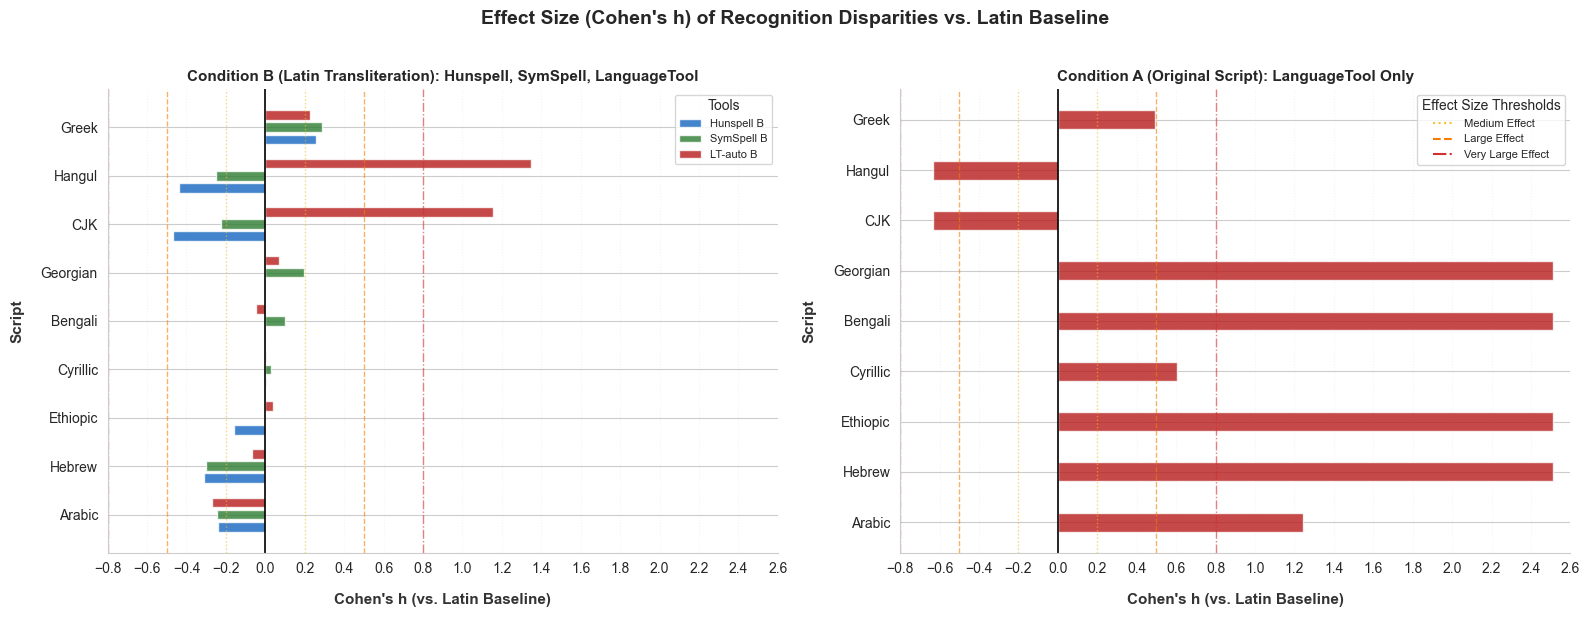

In [295]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines

# ── Configuration & Data Preparation ──────────────────────────────────────────
THRESHOLDS = [
    (0.20, "Medium Effect",  ":",  "#fbc02d"),
    (0.50, "Large Effect",   "--", "#f57c00"),
    (0.80, "Very Large Effect", "-.", "#d32f2f")
]

# Chart 1 Data: COND_B tools on name_script
h_data = {}
for col, label in COND_B:
    tbl = cohens_h_table(df_major, "name_script", col, "Latin")
    h_data[label] = tbl[tbl["group"] != "Latin"].set_index("group")["Cohen_h"]

h_df = pd.DataFrame(h_data).dropna(how="all")
h_df = h_df.loc[h_df.mean(axis=1).sort_values().index]

# Chart 2 Data: LT-auto A only
lt_tbl = cohens_h_table(df_major, "name_script", LT_ORIG_COL, "Latin")
lt_tbl = lt_tbl[lt_tbl["group"] != "Latin"]
lt_tbl = lt_tbl.set_index("group").reindex(h_df.index).reset_index()

# ── Calculate Asymmetric Axis Limits ──────────────────────────────────────────
# Combine all data points to find global min/max
all_vals = np.concatenate([h_df.values.flatten(), lt_tbl["Cohen_h"].values])
all_vals = all_vals[~np.isnan(all_vals)]

raw_min = all_vals.min()
raw_max = all_vals.max()

# Round to nearest 0.2 interval (Floor for min, Ceil for max)
xmin = np.floor(raw_min / 0.2) * 0.2
xmax = np.ceil(raw_max / 0.2) * 0.2

# ── Plotting ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, max(6, len(h_df) * 0.6)), sharey=False)

bar_h = 0.25
y = np.arange(len(h_df))
plot_labels = h_df.columns
offsets = np.linspace(-bar_h, bar_h, len(plot_labels))
bar_colors = ["#1565c0", "#2e7d32", "#b71c1c"]

# --- Chart 1: Condition B ---
for label, offset, color in zip(plot_labels, offsets, bar_colors):
    ax1.barh(y + offset, h_df[label], height=bar_h*0.8, 
             label=label, color=color, alpha=0.8)

# --- Chart 2: LT-auto A ---
ax2.barh(y, lt_tbl["Cohen_h"], height=bar_h*1.5, 
         label="LT-auto (Orig)", color="#b71c1c", alpha=0.8)

# --- Shared Guidelines & Formatting ---
for ax in [ax1, ax2]:
    ax.axvline(0, color="black", linewidth=1.2)
    
    # Guidelines (drawn only where relevant to the data range)
    for val, lbl, ls, col in THRESHOLDS:
        # Negative guidelines
        if -val >= xmin:
            ax.axvline(-val, color=col, linestyle=ls, linewidth=1, alpha=0.6)
        # Positive guidelines
        if val <= xmax:
            ax.axvline(val, color=col, linestyle=ls, linewidth=1, alpha=0.6)
    
    ax.set_yticks(y)
    ax.set_yticklabels(h_df.index)
    ax.set_xlabel("Cohen's h (vs. Latin Baseline)", fontweight="bold", fontsize=11, color="#333333", labelpad=12)
    ax.set_ylabel("Script", fontweight="bold", fontsize=11, color="#333333", labelpad=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis='x', linestyle=':', alpha=0.2)
    
    # Apply asymmetric limits
    ax.set_xlim(xmin, xmax)
    # Ticks at 0.2 intervals
    ax.set_xticks(np.arange(xmin, xmax + 0.1, 0.2))

# --- Titles & Legends ---
ax1.set_title("Condition B (Latin Transliteration): Hunspell, SymSpell, LanguageTool", fontsize=11, fontweight='bold')
ax2.set_title("Condition A (Original Script): LanguageTool Only", fontsize=11, fontweight='bold')

line_handles = [mlines.Line2D([], [], color=col, linestyle=ls, label=lbl) for val, lbl, ls, col in THRESHOLDS]
tool_handles, _ = ax1.get_legend_handles_labels()

ax1.legend(handles=tool_handles, fontsize=8, loc="upper right", title="Tools")
ax2.legend(handles=line_handles, fontsize=8, loc="upper right", title="Effect Size Thresholds")

fig.suptitle("Effect Size (Cohen's h) of Recognition Disparities vs. Latin Baseline", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cohen_h.png', format='png', bbox_inches='tight', dpi=300)

---
## Q1/Q2: Language Origin Analysis

Two language signals are available for every name:

- **** -- primary official language of the predicted country of origin
- **** -- language detected from the name's character patterns
- **** -- whether the two agree (the name "looks like" what you'd expect from its country)

High-agreement names (e.g. Pierre: France, French) are prototypical for their origin.
Low-agreement names (e.g. a Yoruba name from Nigeria, which has English as official language) are
from post-colonial or multilingual contexts -- their phonetic patterns deviate from the
official-language norm, even though that country is technically English-speaking.

The key question: is recognition driven by the official linguistic context of a name's origin,
or by what the name actually looks like? If spell-checkers fail names where the two disagree,
that's evidence the tools are optimised for European orthographic patterns rather than the
full linguistic reality of a country.


Q1: Recognition rates by primary official language -- Condition B, Latin-script names
-- Hunspell B --
group     n  known  rate_%  CI_low  CI_high  CI_width
   fr 20949   2214 10.5700 10.1600  10.9900    0.8330
   en 86909   6707  7.7200  7.5400   7.9000    0.3550
   de  8313    634  7.6300  7.0800   8.2200    1.1420
   nl  6523    440  6.7500  6.1600   7.3800    1.2180
   af 20616   1369  6.6400  6.3100   6.9900    0.6800
   it 15307    992  6.4800  6.1000   6.8800    0.7800
   ar 75911   4668  6.1500  5.9800   6.3200    0.3420
   es 46939   2376  5.0600  4.8700   5.2600    0.3970
   cs  5683    219  3.8500  3.3800   4.3900    1.0020
   hu  8135    298  3.6600  3.2800   4.0900    0.8170
   pt 17831    633  3.5500  3.2900   3.8300    0.5440
   tr 11713    366  3.1200  2.8200   3.4600    0.6310
   hi  9604    208  2.1700  1.8900   2.4800    0.5830
   lt  7326     91  1.2400  1.0100   1.5200    0.5100
   sq  6766     82  1.2100  0.9800   1.5000    0.5240

-- SymSpell B --
group     n  kn

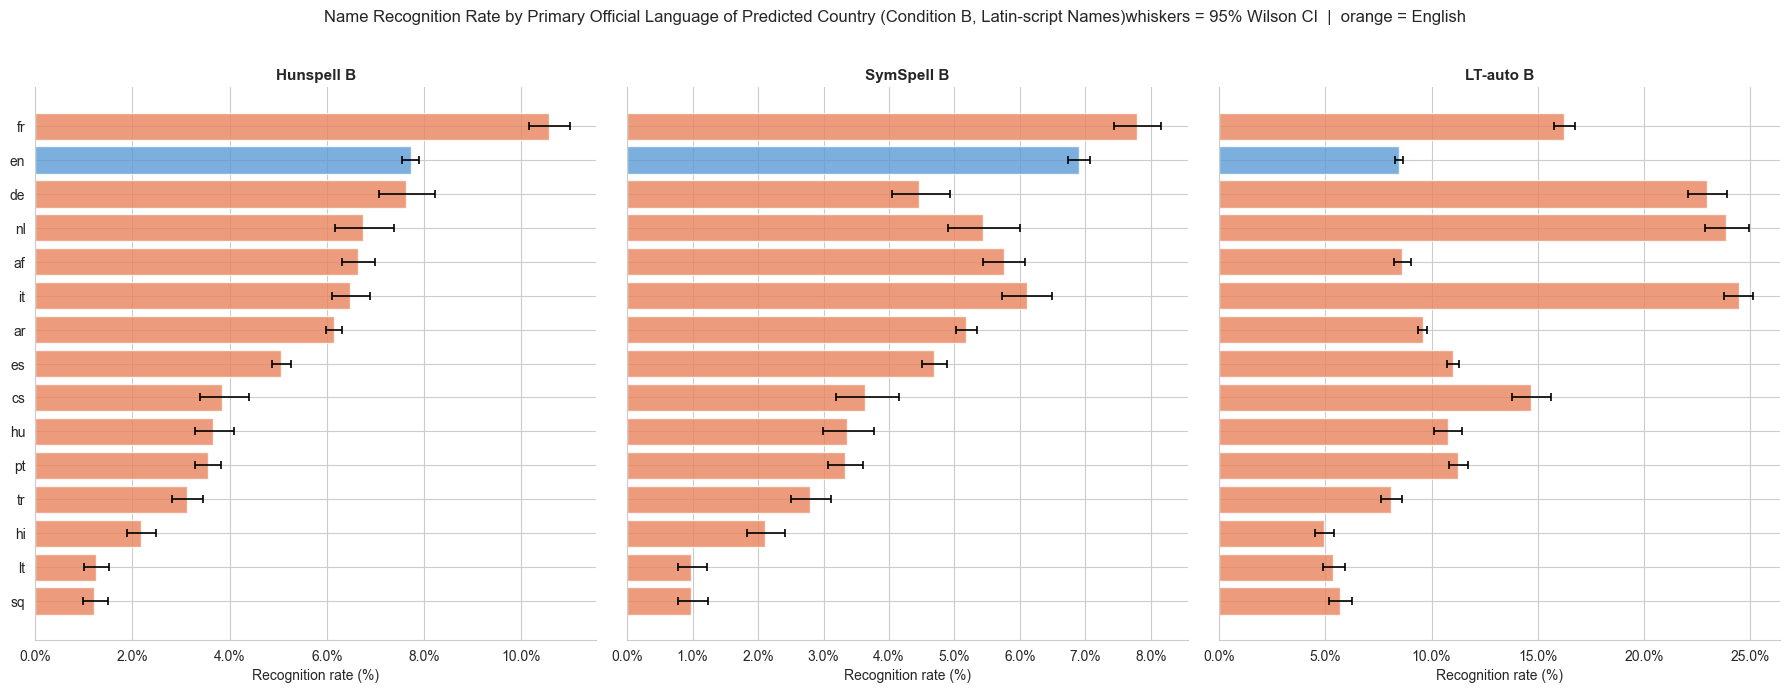

Languages far below English = limited lexical coverage in the English dictionary.
LT-auto B higher for European languages (Spanish, Portuguese, Italian) -- language-specific dictionaries.


In [296]:
# Q1: Recognition rates by primary official language (top_country_langs[0])
# Latin-script names only -- isolates lexical bias from script.

import json as _json

def get_primary_lang(val):
    if not isinstance(val, str) or val == '': return None
    try:
        langs = _json.loads(val)
        return langs[0] if langs else None
    except Exception: return None

df['primary_lang'] = df['top_country_langs'].apply(get_primary_lang)
lat = df_latin_only.copy()
lat['primary_lang'] = df.loc[df_latin_only.index, 'primary_lang']

top_langs = lat['primary_lang'].value_counts().head(15).index.tolist()

print('Q1: Recognition rates by primary official language -- Condition B, Latin-script names')
for col, label in COND_B:
    tbl = recognition_table(lat[lat['primary_lang'].isin(top_langs)], 'primary_lang', col)
    print(f'-- {label} --')
    print(tbl.to_string(index=False))
    print()

lang_sub = lat[lat['primary_lang'].isin(top_langs)]
ref_lang_order = (
    recognition_table(lang_sub, 'primary_lang', 'hunspell_latin_known')
    .sort_values('rate_%', ascending=True)['group'].tolist()
)

fig, axes = plt.subplots(1, 3,
                          figsize=(18, max(5, len(ref_lang_order)*0.45)),
                          sharey=True)

for ax, (col, label) in zip(axes, COND_B):
    tbl = (
        recognition_table(lang_sub, 'primary_lang', col)
        .set_index('group').reindex(ref_lang_order).reset_index()
    )
    colors = ['#5B9BD5' if g == 'en' else '#E8845B' for g in tbl['group']]
    ax.barh(
        tbl['group'], tbl['rate_%'],
        xerr=[tbl['rate_%'] - tbl['CI_low'], tbl['CI_high'] - tbl['rate_%']],
        color=colors, alpha=0.80, capsize=3,
        error_kw={'elinewidth': 1.2, 'capthick': 1.2},
    )
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Recognition rate (%)')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    for spine in ['top','right']: ax.spines[spine].set_visible(False)

fig.suptitle(
    'Name Recognition Rate by Primary Official Language of Predicted Country (Condition B, Latin-script Names)'
    'whiskers = 95% Wilson CI  |  orange = English',
    fontsize=12, y=1.02
)
plt.tight_layout(); plt.show()

print('Languages far below English = limited lexical coverage in the English dictionary.')
print('LT-auto B higher for European languages (Spanish, Portuguese, Italian) -- language-specific dictionaries.')


---
## Recognition Rates by Country of Origin

Uses top_country directly. Restricted to Latin-script names, Condition B. Shows the 5 highest and 5 lowest recognised countries (among those with n >= 1000) to illustrate the contrast between European-centric and globally distributed naming conventions. Tick colour indicates geographic region.

In [297]:
# Recognition rates by top_country -- Latin-script names, Condition B
# Shows the 5 highest and 5 lowest recognised countries (min n=1000),
# plus the 10 most frequent countries for a frequency-unbiased reference.

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from matplotlib.lines import Line2D

REGION_MAP = {
    # Europe
    **{c: "Europe" for c in ["Italy", "France", "Germany", "Spain", "Portugal", "Netherlands", "Belgium", "Sweden", "Norway", "Denmark", "Finland", "Poland", "Czechia", "Hungary", "Austria", "Switzerland", "Greece", "Romania", "Bulgaria", "Croatia", "Serbia", "Albania", "Lithuania", "Estonia", "Slovenia", "Luxembourg", "Malta", "United Kingdom", "Ireland", "Russian Federation", "Iceland", "Moldova, Republic of"]},
    # Northern America
    "United States": "Northern America", "Canada": "Northern America",
    # Latin America & Caribbean
    **{c: "Latin America & Caribbean" for c in ["Brazil", "Mexico", "Colombia", "Argentina", "Chile", "Peru", "Ecuador", "Uruguay", "Bolivia, Plurinational State of", "Puerto Rico", "Jamaica", "Haiti", "Panama", "Honduras", "El Salvador", "Guatemala", "Costa Rica"]},
    # Northern Africa
    **{c: "Northern Africa" for c in ["Egypt", "Libya", "Algeria", "Morocco", "Tunisia", "Sudan"]},
    # Sub-Saharan Africa
    **{c: "Sub-Saharan Africa" for c in ["Burundi", "Djibouti", "Nigeria", "South Africa", "Ghana", "Kenya", "Ethiopia", "Cameroon", "Angola", "Burkina Faso", "Namibia", "Botswana", "Mauritius"]},
    # Western Asia
    **{c: "Western Asia" for c in ["Saudi Arabia", "United Arab Emirates", "Turkiye", "Türkiye", "Cyprus", "Israel", "Jordan", "Lebanon", "Iraq", "Kuwait", "Qatar", "Oman", "Bahrain", "Yemen", "Palestine, State of", "Syrian Arab Republic", "Azerbaijan", "Georgia"]},
    # Central & Southern Asia
    **{c: "Central & Southern Asia" for c in ["Maldives", "Iran, Islamic Republic of", "India", "Pakistan", "Bangladesh", "Afghanistan", "Kazakhstan", "Turkmenistan"]},
    # Eastern & South-eastern Asia
    **{c: "Eastern & SE Asia" for c in ["Brunei Darussalam", "Cambodia", "China", "Korea, Republic of", "Japan", "Taiwan, Province of China", "Hong Kong", "Macao", "Malaysia", "Indonesia", "Philippines", "Singapore"]},
    # Oceania
    "Fiji": "Oceania",
}

REGION_COLOURS = {
    "Europe":                    "#1565c0",
    "Northern America":          "#2e7d32",
    "Latin America & Caribbean": "#558b2f",
    "Northern Africa":           "#e65100",
    "Sub-Saharan Africa":        "#6a1b9a",
    "Western Asia":              "#f57f17",
    "Central & Southern Asia":   "#c62828",
    "Eastern & SE Asia":         "#00838f",
    "Oceania":                   "#757575",
}

MIN_N = 100

# Build per-country recognition rates for all countries meeting MIN_N threshold
rows = []
excluded_list = []
other_list = []

for country, grp in df_latin_only.groupby("top_country"):
    n = len(grp)
    region = REGION_MAP.get(country, "Other")
    
    # Audit: Check for exclusion and missing mapping
    if n < MIN_N:
        excluded_list.append((country, n))
        continue
    if region == "Other":
        other_list.append((country, n))
        
    row = {"country": country, "n": n, "region": region}
    for col, label in COND_B:
        row[label] = round(grp[col].mean() * 100, 2)
    rows.append(row)

all_ctry = pd.DataFrame(rows).sort_values("Hunspell B", ascending=False).reset_index(drop=True)

print(f"--- THRESHOLD AUDIT: n >= {MIN_N} ---")
print(f"Countries Included: {len(all_ctry)}")
print(f"Countries Excluded (n < {MIN_N}): {len(excluded_list)}")
for c, n in sorted(excluded_list, key=lambda x: x[1]):
    print(f"  - {c}: {n}")

print(f"\n--- MAPPING AUDIT: 'Other' Category ---")
print(f"Included countries needing a region assignment: {len(other_list)}")
for c, n in sorted(other_list, key=lambda x: x[1], reverse=True):
    print(f"  - {c}: {n}")

# Show summary table
print("\n--- FINAL DATASET PREVIEW ---")
print(f"Countries with n >= {MIN_N} in Latin-script subset: {len(all_ctry)}")
print(all_ctry[["country", "n", "region", "Hunspell B", "SymSpell B", "LT-auto B"]].to_string(index=False))


--- THRESHOLD AUDIT: n >= 100 ---
Countries Included: 104
Countries Excluded (n < 100): 1
  - El Salvador: 70

--- MAPPING AUDIT: 'Other' Category ---
Included countries needing a region assignment: 0

--- FINAL DATASET PREVIEW ---
Countries with n >= 100 in Latin-script subset: 104
                        country     n                    region  Hunspell B  SymSpell B  LT-auto B
                         Sweden  1413                    Europe     18.7500      3.7500    30.2900
                 United Kingdom  3909                    Europe     18.3700     12.8400    18.3200
                         Norway  1848                    Europe     16.6700      2.0000    27.0600
                  United States 24891          Northern America     16.0500     15.4400    15.9200
                        Algeria  9415           Northern Africa     15.3900     12.3500    20.0800
                          Egypt  8324           Northern Africa     15.0600     12.9500    17.7000
                       

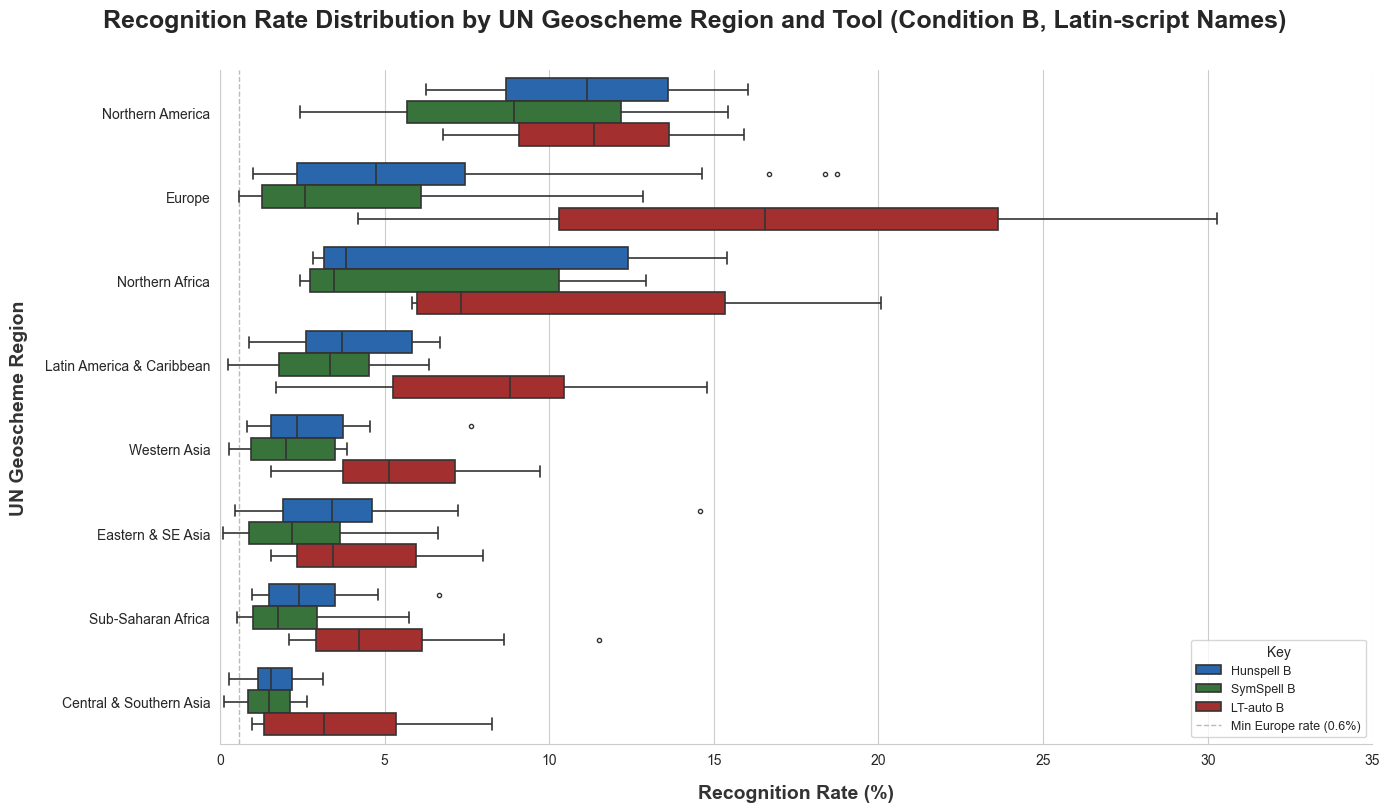

In [298]:
# Note: dots visible outside the boxes are flier (outlier) points -- country-level
# recognition rates that fall beyond 1.5x IQR from the box edge. With few countries
# per region the whiskers are short, so these are expected and meaningful, not noise.

import seaborn as sns

TOOL_PALETTE = {"Hunspell B": "#1565c0", "SymSpell B": "#2e7d32", "LT-auto B": "#b71c1c"}

# Only show plots for regions with multiple countries (discludes Oceania as only includes Fiji)
region_counts = all_ctry['region'].value_counts()
valid_regions = region_counts[region_counts > 1].index.tolist()
all_ctry_filtered = all_ctry[all_ctry['region'].isin(valid_regions)]

# Rebuild df_long from all_ctry so region assignments reflect the current REGION_MAP
df_long = all_ctry_filtered.melt(
    id_vars=["country", "region"],
    value_vars=["Hunspell B", "SymSpell B", "LT-auto B"],
    var_name="Tool", value_name="Rate"
)

# Sort UN Geoscheme regions by mean recognition rate (highest first)
region_order = (
    df_long.groupby("region")["Rate"].mean()
    .sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.set_style("whitegrid")

sns.boxplot(
    data=df_long,
    x="Rate", y="region",
    hue="Tool",
    order=region_order,
    palette=TOOL_PALETTE,
    fliersize=3,
    linewidth=1.2,
    ax=ax
)

euro_min = df_long[df_long["region"] == "Europe"]["Rate"].min()
ax.axvline(euro_min, color="#555555", linestyle="--", linewidth=1,
           alpha=0.4, label=f"Min Europe rate ({euro_min:.1f}%)")

ax.set_xlim(0, 35)
ax.set_xlabel("Recognition Rate (%)", fontweight='bold', fontsize=14, color='#333333', labelpad=12)
ax.set_ylabel("UN Geoscheme Region", fontweight='bold', fontsize=14, color='#333333', labelpad=12)
fig.suptitle(
    "Recognition Rate Distribution by UN Geoscheme Region and Tool (Condition B, Latin-script Names)",
    fontsize=18, fontweight="bold", y=1.01
)
ax.legend(title="Key", loc="lower right", fontsize=9)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
    
plt.tight_layout()
plt.savefig('regional_recognition_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

Recognition rates by country-language alignment -- Latin-script names only, Condition B
 condition                    group      n  rate_%  CI_low  CI_high
Hunspell B Matches country language  48241  7.7900  7.5600   8.0400
Hunspell B           Does not match 415213  5.1600  5.0900   5.2300
SymSpell B Matches country language  48241  6.4900  6.2700   6.7100
SymSpell B           Does not match 415213  4.2400  4.1800   4.3000
 LT-auto B Matches country language  48241 22.7200 22.3400  23.0900
 LT-auto B           Does not match 415213  9.0500  8.9600   9.1400

If gap persists here, tools penalise phonetic non-conformity to European orthographic
norms even within a shared Latin alphabet.


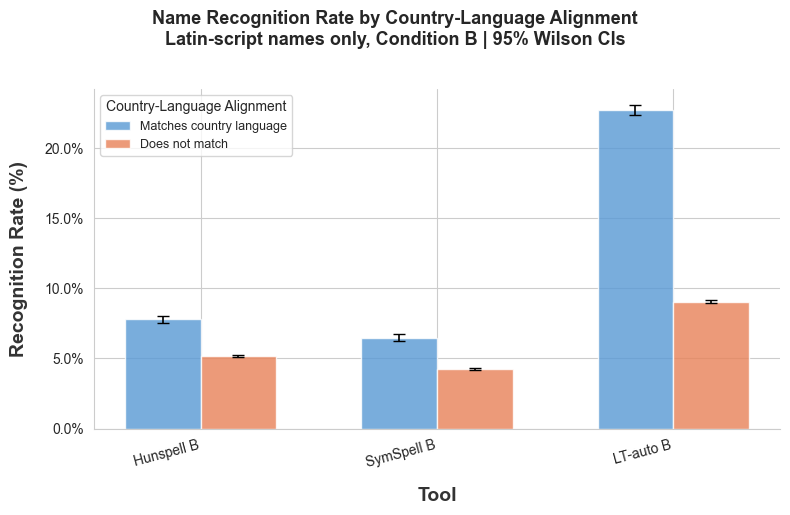

In [299]:
# country_lang_comp: whether the language detected from name character patterns
# matches an official language of the predicted country of origin.
#   True  -- phonetically conforms (e.g. Pierre -> France / French)
#   False -- does not match: post-colonial, diaspora, or multilingual contexts
#            (e.g. a Yoruba name from Nigeria, officially English-speaking)
#
# Latin-script names only -- script is already controlled for.
# A persistent recognition gap between True and False groups implicates phonetic
# non-conformity to European orthographic norms, not script incompatibility.

comp_flag_lat = df_latin_only["country_lang_comp"].astype(bool)
group_labels = {True: "Matches country language", False: "Does not match"}

lat_rows = []
for col, label in COND_B:
    for flag in (True, False):
        sub = df_latin_only[comp_flag_lat == flag]
        n = len(sub); k = int(sub[col].sum())
        lo, hi = proportion_confint(k, n, alpha=0.05, method="wilson")
        lat_rows.append({"condition": label, "group": group_labels[flag],
                         "n": n, "rate_%": round(k/n*100, 2),
                         "CI_low": round(lo*100, 2), "CI_high": round(hi*100, 2)})

lat_df = pd.DataFrame(lat_rows)
print("Recognition rates by country-language alignment -- Latin-script names only, Condition B")
print(lat_df.to_string(index=False))
print("\nIf gap persists here, tools penalise phonetic non-conformity to European orthographic")
print("norms even within a shared Latin alphabet.")

cond_lbls = lat_df["condition"].unique()
x = np.arange(len(cond_lbls))
w = 0.32

fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
ax.set_facecolor("white")

for i, (flag, gname, color) in enumerate([
    (True,  "Matches country language", "#5B9BD5"),
    (False, "Does not match",           "#E8845B"),
]):
    grp = lat_df[lat_df["group"] == gname]
    vals   = grp["rate_%"].values
    err_lo = (grp["rate_%"] - grp["CI_low"]).values
    err_hi = (grp["CI_high"] - grp["rate_%"]).values
    ax.bar(x + i*w, vals, w, label=gname, color=color, alpha=0.82,
           yerr=[err_lo, err_hi], capsize=4,
           error_kw={"elinewidth": 1.2})

ax.set_xticks(x + w/2)
ax.set_xticklabels(cond_lbls, rotation=15, ha="right")
ax.set_xlabel("Tool", fontweight='bold', fontsize=14, color='#333333', labelpad=12)
ax.set_ylabel("Recognition Rate (%)", fontweight='bold', fontsize=14, color='#333333', labelpad=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title="Country-Language Alignment", fontsize=9)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.suptitle(
    "Name Recognition Rate by Country-Language Alignment\n"
    "Latin-script names only, Condition B | 95% Wilson CIs",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig('country_lang_comp_recognition_rate.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Q2 (continued): Logistic Regression

Regression estimates the effect of name origin *controlling for* name length and
origin-confidence score (). If the group effect survives controls,
the bias argument is stronger.

**Script model:** Latin = reference. OR < 1.0 means lower odds than Latin-script names.
**Origin model:** British = reference, Latin-script names only. Any OR < 1.0 here is lexical,
not script-related.

Runtime: ~2-5 min per model at this n.


In [300]:
# Q2: Logistic regression by script, one model per condition
# Latin is the reference category.
#
# Note: LT-auto A has near-zero recognition for CJK and Hangul (language detection
# cannot help those scripts), causing perfect separation for those categories.
# The Newton-Raphson solver fails with a singular Hessian in that case.
# We fall back to BFGS, which handles separation more gracefully.

def logreg_script(data, outcome_col, cond_label):
    print(f'{"="*60}')
    print(f'Condition: {cond_label}  |  outcome: {outcome_col}')
    print(f'Predictors: script (ref=Latin), top_country_prob, name_length')
    print(f'{"="*60}')

    reg = data.copy()
    order = ['Latin'] + [s for s in MAJOR_SCRIPTS if s != 'Latin']
    reg['script_cat'] = pd.Categorical(reg['name_script'], categories=order)
    reg[outcome_col]  = reg[outcome_col].astype(int)

    formula = f'{outcome_col} ~ C(script_cat) + top_country_prob + name_length'

    # Try Newton (default, faster); fall back to BFGS if Hessian is singular.
    # Singular Hessian occurs when a category has near-zero or near-100% recognition
    # (perfect separation), as happens for CJK/Hangul under LT-auto A.
    try:
        model = smf.logit(formula, data=reg).fit(maxiter=200, disp=False)
        solver_used = 'newton'
    except np.linalg.LinAlgError:
        print('  [Newton failed -- falling back to BFGS (handles perfect separation)]')
        model = smf.logit(formula, data=reg).fit(
            method='bfgs', maxiter=500, disp=False
        )
        solver_used = 'bfgs'

    params = model.params
    ci     = model.conf_int()
    or_df  = pd.DataFrame({
        'OR':      np.exp(params).round(4),
        'CI_low':  np.exp(ci.iloc[:, 0]).round(4),
        'CI_high': np.exp(ci.iloc[:, 1]).round(4),
        'p':       model.pvalues,
    })
    or_df['sig'] = or_df['p'].apply(
        lambda v: '***' if v < 0.001 else ('**' if v < 0.01 else ('*' if v < 0.05 else 'ns'))
    )
    or_df['p'] = or_df['p'].apply(lambda v: f'{v:.2e}')
    or_df.index = (
        or_df.index
        .str.replace(r'C\(script_cat\)\[T\.', '', regex=True)
        .str.replace(']', '', regex=False)
    )

    print(f'Solver: {solver_used}')
    print(f'Pseudo R2 (McFadden): {1 - model.llf / model.llnull:.4f}')
    print(f'n = {len(reg):,}')
    print(or_df.to_string())
    print('OR < 1.0 = lower odds of recognition vs Latin.')
    print('OR ~ 0 for a script = near-complete barrier (e.g. CJK under LT-auto A).')
    return or_df


# Run all conditions; accumulate COND_B results into plot_df for the OR chart
_cond_b_labels = {col: lbl for col, lbl in COND_B}
_plot_rows = []
for col, label in FOCUS_CONDS:
    result = logreg_script(df_major, col, label)
    if col in _cond_b_labels:
        for script, row in result.iterrows():
            if script in ['Intercept', 'top_country_prob', 'name_length']:
                continue
            _plot_rows.append({
                'Condition': label,
                'Script':    script,
                'OR':        row['OR'],
                'Lower':     row['CI_low'],
                'Upper':     row['CI_high'],
            })

plot_df = pd.DataFrame(_plot_rows)
conds   = [lbl for _, lbl in COND_B]
print(f'plot_df built: {len(plot_df)} rows, conditions: {conds}')


Condition: Hunspell B  |  outcome: hunspell_latin_known
Predictors: script (ref=Latin), top_country_prob, name_length
Solver: newton
Pseudo R2 (McFadden): 0.0696
n = 567,985
                     OR  CI_low  CI_high          p  sig
Intercept        0.6235  0.5938   0.6546   1.70e-80  ***
Arabic           0.1687  0.1530   0.1859  2.65e-281  ***
Cyrillic         1.2467  1.1783   1.3190   1.81e-14  ***
CJK              0.0000  0.0000      inf   1.00e+00   ns
Hangul           0.0019  0.0006   0.0058   1.44e-27  ***
Hebrew           0.0711  0.0483   0.1046   5.03e-41  ***
Bengali          0.7363  0.6231   0.8699   3.21e-04  ***
Greek            3.6085  3.2388   4.0203  8.32e-120  ***
Georgian         0.9664  0.7964   1.1728   7.29e-01   ns
Ethiopic         0.2229  0.1355   0.3668   3.45e-09  ***
top_country_prob 0.3072  0.2923   0.3228   0.00e+00  ***
name_length      0.7588  0.7527   0.7649   0.00e+00  ***
OR < 1.0 = lower odds of recognition vs Latin.
OR ~ 0 for a script = near-complete ba

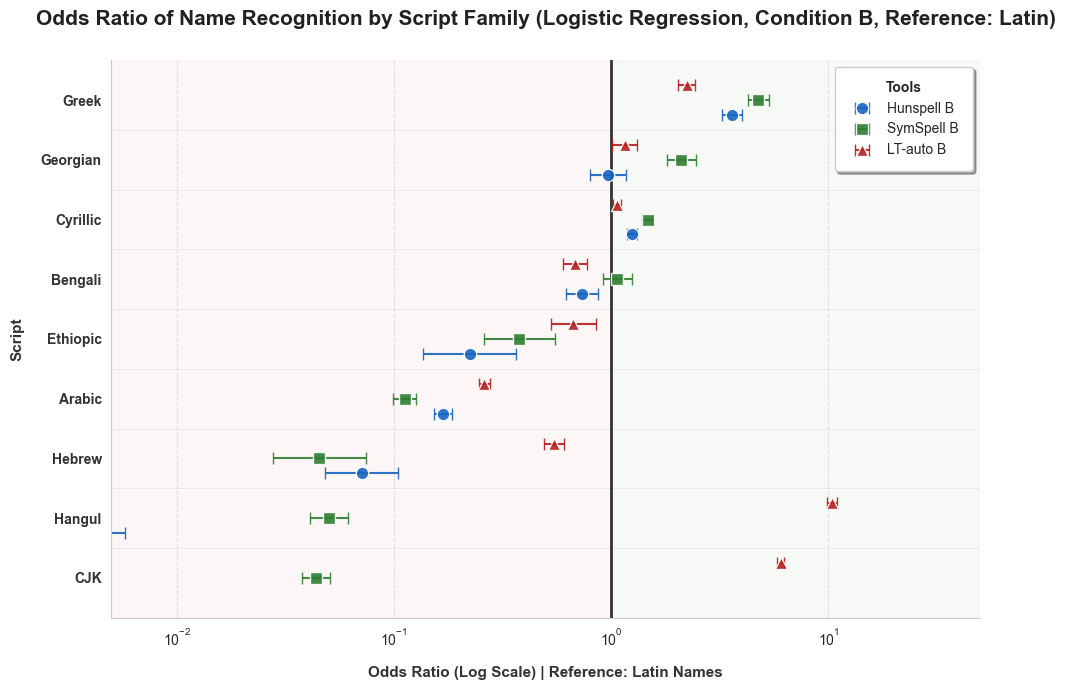

In [301]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. COHESIVE STYLING VARIABLES ---
colors = {"Hunspell B": "#1565c0", "SymSpell B": "#2e7d32", "LT-auto B": "#b71c1c"}
markers = {"Hunspell B": "o", "SymSpell B": "s", "LT-auto B": "^"}
story_order = ['CJK', 'Hangul', 'Hebrew', 'Arabic', 'Ethiopic', 'Bengali', 'Cyrillic', 'Georgian', 'Greek']
y_pos = np.arange(len(story_order))

# --- 2. PLOT INITIALIZATION ---
fig, ax = plt.subplots(figsize=(10, 7), facecolor='white')
ax.set_facecolor('white')

# --- 3. PLOT WITH JITTER ---
width = 0.25 
for i, cond in enumerate(conds):
    subset = plot_df[plot_df['Condition'] == cond].set_index('Script').reindex(story_order)
    
    ax.errorbar(subset['OR'], y_pos + (i * width - width), 
                xerr=[subset['OR'] - subset['Lower'], subset['Upper'] - subset['OR']],
                fmt=markers[cond], color=colors[cond], label=cond,
                markersize=9, capsize=4, elinewidth=1.5, alpha=0.9, 
                markeredgecolor='white', markeredgewidth=1)

# --- 4. COHESIVE STRUCTURAL ELEMENTS ---
ax.axvline(1, color='#333333', linewidth=2, zorder=1) 
ax.set_xscale('log')
ax.set_xlim(0.005, 50) 

# Cohesive Shading
ax.axvspan(0.005, 1, color='#b71c1c', alpha=0.04, zorder=0) 
ax.axvspan(1, 50, color='#2e7d32', alpha=0.04, zorder=0)    

# --- NEW: ADD HORIZONTAL BOUNDARY LINES ---
# We loop through the gaps between scripts to draw faint divider lines
for y in range(len(story_order) - 1):
    ax.axhline(y + 0.5, color='#bdbdbd', linestyle='-', linewidth=0.5, alpha=0.3, zorder=0)

# --- 5. TEXT & AXIS STYLING ---
ax.set_yticks(y_pos)
ax.set_yticklabels(story_order, fontweight='bold', color='#333333')
ax.set_xlabel("Odds Ratio (Log Scale) | Reference: Latin Names", 
              fontweight='bold', fontsize=11, color='#333333', labelpad=12)
ax.set_ylabel("Script", fontweight="bold", fontsize=11, color="#333333", labelpad=12)
ax.set_title("Odds Ratio of Name Recognition by Script Family (Logistic Regression, Condition B, Reference: Latin)", 
             fontsize=15, fontweight='bold', color='#212121', pad=25)

# Standardized Grids (Vertical only now, as we've added custom horizontals)
ax.grid(True, axis='x', which='major', linestyle='--', alpha=0.4, color='#bdbdbd')
ax.grid(False, axis='y') 

# --- 6. LEGEND STYLING ---
legend = ax.legend(loc='upper right', frameon=True, shadow=True, 
                   title="Tools", fontsize=10, borderpad=1)
legend.get_title().set_fontweight('bold')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('log_reg_lanes.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [302]:
# Q2: Logistic regression by origin category -- Condition B, Latin-script names only.
# British is the reference category.
# Any OR < 1.0 here cannot be explained by script -- it is lexical bias.

def logreg_ethnicity(data, outcome_col, cond_label):
    print(f'\n{"="*60}')
    print(f'Condition: {cond_label}  |  outcome: {outcome_col}')
    print(f'Predictors: origin category (ref=British), top_country_prob, name_length')
    print(f'LATIN-SCRIPT NAMES ONLY')
    print(f'{"="*60}')

    reg = data[data['eth_short'] != 'Unknown'].copy()
    counts = reg['eth_short'].value_counts()
    reg    = reg[reg['eth_short'].isin(counts[counts >= 100].index)].copy()

    eth_order     = ['British'] + [e for e in reg['eth_short'].unique() if e != 'British']
    reg['eth_cat']   = pd.Categorical(reg['eth_short'], categories=eth_order)
    reg[outcome_col] = reg[outcome_col].astype(int)

    model = smf.logit(
        f'{outcome_col} ~ C(eth_cat) + top_country_prob + name_length',
        data=reg
    ).fit(maxiter=200, disp=False)

    params = model.params
    ci     = model.conf_int()
    or_df  = pd.DataFrame({
        'OR':      np.exp(params).round(4),
        'CI_low':  np.exp(ci.iloc[:, 0]).round(4),
        'CI_high': np.exp(ci.iloc[:, 1]).round(4),
        'p':       model.pvalues,
    })
    or_df['sig'] = or_df['p'].apply(
        lambda v: '***' if v < 0.001 else ('**' if v < 0.01 else ('*' if v < 0.05 else 'ns'))
    )
    or_df['p'] = or_df['p'].apply(lambda v: f'{v:.2e}')
    or_df.index = (
        or_df.index
        .str.replace(r'C\(eth_cat\)\[T\.', '', regex=True)
        .str.replace(']', '', regex=False)
    )

    print(f'Pseudo R2 (McFadden): {1 - model.llf / model.llnull:.4f}')
    print(f'n = {len(reg):,}\n')
    print(or_df.to_string())
    print('\nOR < 1.0 = lower odds of recognition vs British (lexical bias, not script).')


for col, label in COND_B:
    logreg_ethnicity(df_latin_only, col, label)



Condition: Hunspell B  |  outcome: hunspell_latin_known
Predictors: origin category (ref=British), top_country_prob, name_length
LATIN-SCRIPT NAMES ONLY
Pseudo R2 (McFadden): 0.0669
n = 463,454

                       OR  CI_low  CI_high          p  sig
Intercept          0.8914  0.8391   0.9469   1.91e-04  ***
Muslim             0.3516  0.3304   0.3743  2.39e-236  ***
EastAsian          0.5399  0.5201   0.5605  9.58e-229  ***
Italian            0.7459  0.6983   0.7967   2.92e-18  ***
Germanic           0.8038  0.7454   0.8667   1.36e-08  ***
EastEuropean       0.6426  0.5947   0.6944   5.28e-29  ***
Africans           0.1541  0.1357   0.1750  4.60e-182  ***
Japanese           0.3174  0.2945   0.3420  1.08e-198  ***
Nordic             0.7856  0.7528   0.8198   1.17e-28  ***
IndianSubContinent 0.2687  0.2541   0.2842   0.00e+00  ***
Jewish             0.3764  0.3439   0.4120  9.52e-100  ***
French             1.9617  1.7914   2.1482   6.44e-48  ***
Hispanic           0.7226  0.6716   0

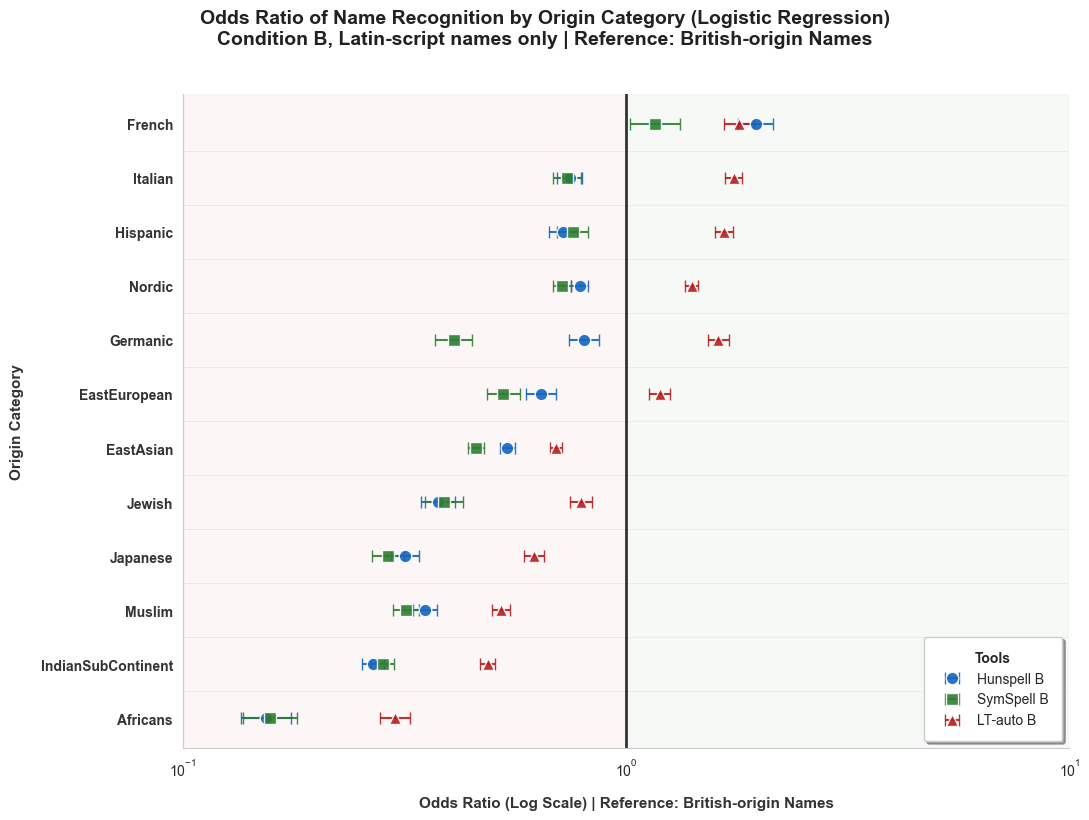

In [303]:
# Origin-category logistic regression -- forest plot
# Mirrors the script-level forest plot but for ethnicolr origin categories.
# Reference: British-origin names. OR < 1.0 = lexical bias (not script).
import matplotlib.pyplot as plt
import numpy as np

FOREST_COLOURS = {"Hunspell B": "#1565c0", "SymSpell B": "#2e7d32", "LT-auto B": "#b71c1c"}
FOREST_MARKERS = {"Hunspell B": "o", "SymSpell B": "s", "LT-auto B": "^"}

or_results = {}
for col, label in COND_B:
    reg = df_latin_only[df_latin_only["eth_short"] != "Unknown"].copy()
    counts = reg["eth_short"].value_counts()
    reg = reg[reg["eth_short"].isin(counts[counts >= 100].index)].copy()
    eth_order = ["British"] + [e for e in sorted(reg["eth_short"].unique()) if e != "British"]
    reg["eth_cat"] = pd.Categorical(reg["eth_short"], categories=eth_order)
    reg[col] = reg[col].astype(int)
    model = smf.logit(
        f"{col} ~ C(eth_cat) + top_country_prob + name_length", data=reg
    ).fit(maxiter=200, disp=False)
    params = model.params
    ci = model.conf_int()
    or_df = pd.DataFrame({
        "OR":    np.exp(params),
        "Lower": np.exp(ci.iloc[:, 0]),
        "Upper": np.exp(ci.iloc[:, 1]),
    })
    or_df.index = (or_df.index
        .str.replace(r"C\(eth_cat\)\[T\.", "", regex=True)
        .str.replace("]", "", regex=False))
    keep = [idx for idx in or_df.index
            if idx not in ["Intercept", "top_country_prob", "name_length"]]
    or_results[label] = or_df.loc[keep]

# Order by mean OR ascending (most penalised at top)
mean_or = pd.concat([or_results[l]["OR"].rename(l) for l in or_results], axis=1).mean(axis=1)
story_order = mean_or.sort_values().index.tolist()
y_pos = np.arange(len(story_order))

fig, ax = plt.subplots(figsize=(11, 8), facecolor="white")
ax.set_facecolor("white")

for i, (col, label) in enumerate(COND_B):
    subset = or_results[label].reindex(story_order)
    ax.errorbar(
        subset["OR"], y_pos,
        xerr=[subset["OR"] - subset["Lower"], subset["Upper"] - subset["OR"]],
        fmt=FOREST_MARKERS[label], color=FOREST_COLOURS[label], label=label,
        markersize=9, capsize=4, elinewidth=1.5, alpha=0.9,
        markeredgecolor="white", markeredgewidth=1
    )

ax.axvline(1, color="#333333", linewidth=2, zorder=1)
ax.set_xscale("log")

# UPDATED AXIS LIMITS: 10^-1 to 10^1
ax.set_xlim(0.1, 10)
ax.axvspan(0.1, 1, color="#b71c1c", alpha=0.04, zorder=0)
ax.axvspan(1, 10, color="#2e7d32", alpha=0.04, zorder=0)

for y in range(len(story_order) - 1):
    ax.axhline(y + 0.5, color="#bdbdbd", linestyle="-", linewidth=0.5, alpha=0.3, zorder=0)

ax.set_yticks(y_pos)
ax.set_yticklabels(story_order, fontweight="bold", color="#333333")
ax.set_xlabel("Odds Ratio (Log Scale) | Reference: British-origin Names",
              fontweight="bold", fontsize=11, color="#333333", labelpad=12)
ax.set_ylabel("Origin Category", fontweight="bold", fontsize=11, color="#333333", labelpad=12)
ax.grid(True, axis="x", which="major", linestyle="--", alpha=0.4, color="#bdbdbd")
ax.grid(False, axis="y")
fig.suptitle(
    "Odds Ratio of Name Recognition by Origin Category (Logistic Regression)\n"
    "Condition B, Latin-script names only | Reference: British-origin Names",
    fontsize=14, fontweight="bold", color="#212121", y=1.02
)
legend = ax.legend(loc="lower right", frameon=True, shadow=True,
                   title="Tools", fontsize=10, borderpad=1)
legend.get_title().set_fontweight("bold")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('log_reg_eth_region.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Q3: Correction Behaviour

When a name is flagged, what does the spell-checker suggest? Each correction is
passed through ethnicolr to predict its likely origin. For each source-origin group:

- **pct_European_%** -- share of corrections predicted as European-origin
- **pct_same_origin_%** -- share staying within the same origin category
- **top_3_correction_origins** -- most common correction origins

If non-European-origin names consistently receive European-origin suggestions at higher rates than
European-origin names do, that's a correction skew -- the tool is not just failing to recognise
the name, it's actively pushing toward Europeanised alternatives.


In [304]:
# Parse correction_match JSON fields
def extract_corr_race(val):
    """Extract ethnicolr_race from the correction_match JSON string."""
    if not isinstance(val, str) or val == '':
        return None
    try:
        return json.loads(val).get('ethnicolr_race')
    except (json.JSONDecodeError, AttributeError):
        return None


CORR_COLS = [
    ('hunspell_latin_correction_match', 'Hunspell'),
    ('symspell_latin_correction_match', 'SymSpell'),
    ('lt_auto_latin_correction_match',  'LT-auto'),
]

for col, label in CORR_COLS:
    race_col  = f'{label}_corr_race'
    eth_col   = f'{label}_corr_eth'
    df[race_col] = df[col].apply(extract_corr_race)
    df[eth_col]  = df[race_col].str.split(',').str[-1].fillna('None')

print('Names with a matched correction (Condition B):')
for col, label in CORR_COLS:
    n = (df[f'{label}_corr_eth'] != 'None').sum()
    print(f'  {label}: {n:,} ({n/len(df)*100})')

Names with a matched correction (Condition B):
  Hunspell: 237,061 (41.51477685857786)
  SymSpell: 289,612 (50.71765307480543)
  LT-auto: 197,875 (34.65241634385705)


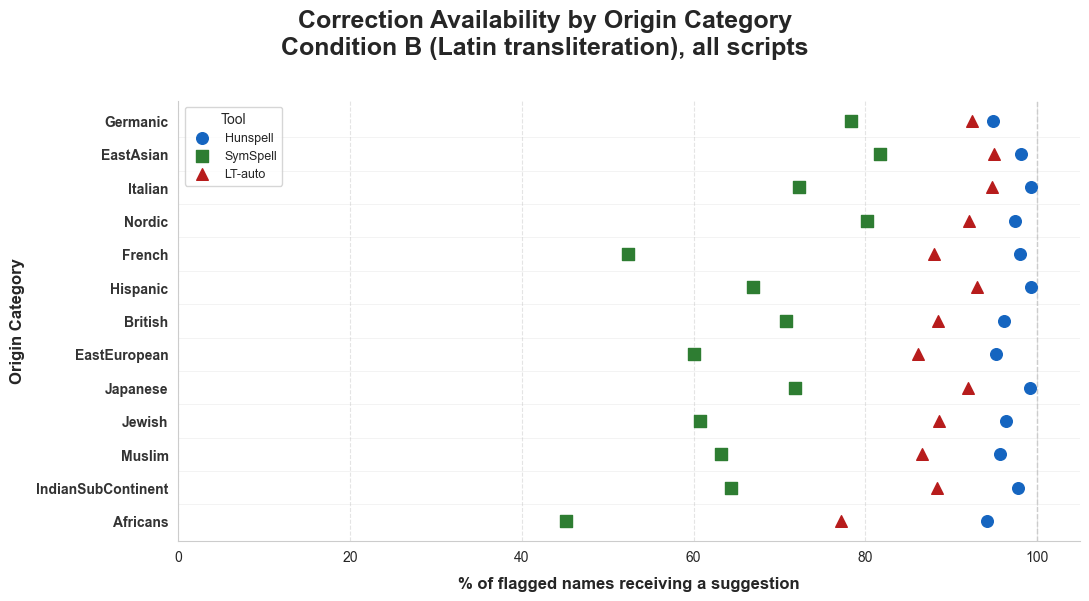

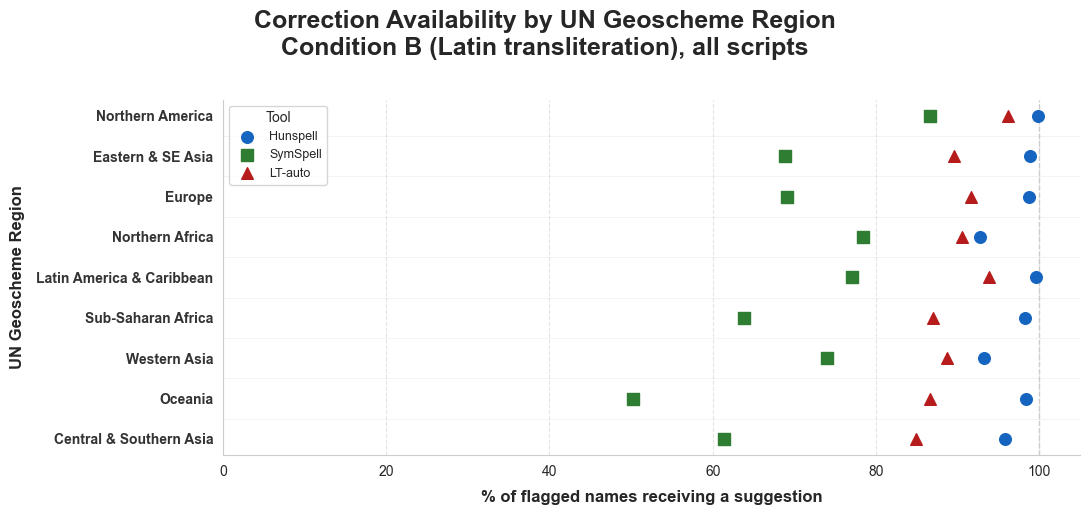

In [305]:
# Q3: Correction Availability
# % of flagged names that receive any correction suggestion,
# by ethnicolr origin category and UN Geoscheme region (saved separately).
import matplotlib.pyplot as plt
import numpy as np

TOOL_PALETTE = {"Hunspell": "#1565c0", "SymSpell": "#2e7d32", "LT-auto": "#b71c1c"}
TOOL_MARKERS = {"Hunspell": "o", "SymSpell": "s", "LT-auto": "^"}
CORR_MAP = [
    ("Hunspell", "hunspell_latin_known", "hunspell_latin_correction"),
    ("SymSpell", "symspell_latin_known", "symspell_latin_correction"),
    ("LT-auto",  "lt_auto_latin_known",  "lt_auto_latin_correction"),
]

eth_counts = df["eth_short"].value_counts()
valid_eth  = eth_counts[eth_counts >= 100].index
eth_sub    = df[(df["eth_short"].isin(valid_eth)) & (df["eth_short"] != "Unknown")].copy()

eth_avail = {}
for tool, known_col, corr_col in CORR_MAP:
    flagged = eth_sub[eth_sub[known_col] == 0]
    eth_avail[tool] = (
        flagged.groupby("eth_short").apply(
            lambda g: (g[corr_col].notna() & (g[corr_col].str.strip() != "")).mean() * 100
        ).rename(tool)
    )

eth_order = (
    eth_sub.groupby("eth_short")[[
        "hunspell_latin_known", "symspell_latin_known", "lt_auto_latin_known"
    ]].mean().mean(axis=1).sort_values().index.tolist()
)

lat_region = df.copy()
lat_region["region"] = lat_region["top_country"].map(REGION_MAP)
lat_region = lat_region[lat_region["region"].notna() & (lat_region["region"] != "Other")]

reg_avail = {}
for tool, known_col, corr_col in CORR_MAP:
    flagged = lat_region[lat_region[known_col] == 0]
    reg_avail[tool] = (
        flagged.groupby("region").apply(
            lambda g: (g[corr_col].notna() & (g[corr_col].str.strip() != "")).mean() * 100
        ).rename(tool)
    )

reg_order = (
    lat_region.groupby("region")[[
        "hunspell_latin_known", "symspell_latin_known", "lt_auto_latin_known"
    ]].mean().mean(axis=1).sort_values().index.tolist()
)

def _avail_plot(avail_dict, order, ylabel, title, filename):
    y_pos = np.arange(len(order))
    fig, ax = plt.subplots(figsize=(11, max(5, len(order) * 0.45)), facecolor="white")
    ax.set_facecolor("white")
    for tool, series in avail_dict.items():
        vals = series.reindex(order).values
        ax.scatter(vals, y_pos, color=TOOL_PALETTE[tool],
                   marker=TOOL_MARKERS[tool], s=70, label=tool, zorder=3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(order, fontweight="bold", color="#333333")
    ax.set_xlabel("% of flagged names receiving a suggestion",
                  fontweight="bold", fontsize=12, labelpad=8)
    ax.set_ylabel(ylabel, fontweight="bold", fontsize=12, labelpad=8)
    ax.set_xlim(0, 105)
    ax.axvline(100, color="#cccccc", linewidth=1, linestyle="--")
    ax.grid(True, axis="x", linestyle="--", alpha=0.4, color="#bdbdbd")
    ax.grid(False, axis="y")
    for y in range(len(order) - 1):
        ax.axhline(y + 0.5, color="#bdbdbd", linewidth=0.4, alpha=0.3)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.legend(title="Tool", fontsize=9, loc="upper left", frameon=True)
    fig.suptitle(title, fontsize=18, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

_avail_plot(
    eth_avail, eth_order, "Origin Category",
    "Correction Availability by Origin Category\nCondition B (Latin transliteration), all scripts",
    "correction_availability_ethnicolr.png"
)
_avail_plot(
    reg_avail, reg_order, "UN Geoscheme Region",
    "Correction Availability by UN Geoscheme Region\nCondition B (Latin transliteration), all scripts",
    "correction_availability_un_region.png"
)

In [306]:
# For each tool: group names by source origin, show where corrections point
print('Correction direction -- Condition B (Latin transliteration)')
print('For each source-origin group, what fraction of corrections point to European-origin names?')
print('European-origin = British + Germanic + Nordic + French + Italian\n')

for col, label in CORR_COLS:
    eth_col  = f'{label}_corr_eth'
    has_corr = df[(df[eth_col] != 'None') & (df['eth_short'] != 'Unknown')].copy()

    if has_corr.empty:
        print(f'{label}: no corrections found.\n')
        continue

    rows = []
    for src, grp in has_corr.groupby('eth_short'):
        if len(grp) < 20:
            continue
        n_total  = len(grp)
        n_west   = grp[eth_col].isin(EUROPEAN_ETH).sum()
        n_same   = (grp[eth_col] == src).sum()
        top3     = grp[eth_col].value_counts().head(3)
        rows.append({
            'source_origin':        src,
            'n_corrections':        n_total,
            'pct_European_%':        round(n_west / n_total * 100, 1),
            'pct_same_origin_%':    round(n_same / n_total * 100, 1),
            'top_3_correction_origins': ', '.join(f'{k}({v})' for k, v in top3.items()),
        })

    if rows:
        tbl = pd.DataFrame(rows).sort_values('pct_European_%', ascending=False)
        print(f'-- {label} --')
        print(tbl.to_string(index=False))
        print()

print('pct_European_% > 50 means more than half of corrections point to European-origin names.')
print('Compare European-origin rows (e.g. British) to non-European-origin rows to gauge the skew.')

Correction direction -- Condition B (Latin transliteration)
For each source-origin group, what fraction of corrections point to European-origin names?
European-origin = British + Germanic + Nordic + French + Italian

-- Hunspell --
     source_origin  n_corrections  pct_European_%  pct_same_origin_%                                  top_3_correction_origins
           British          38247         66.9000            47.1000             British(18009), EastAsian(7131), Nordic(4292)
            Nordic          25487         65.5000            37.0000              Nordic(9438), British(4527), EastAsian(4467)
           Italian           8501         63.9000            30.0000             Italian(2547), British(1421), EastAsian(1187)
            French           1938         63.4000            17.4000                 British(511), French(338), EastAsian(322)
          Germanic           6392         59.4000            22.1000             Germanic(1412), EastAsian(1209), British(974)
      

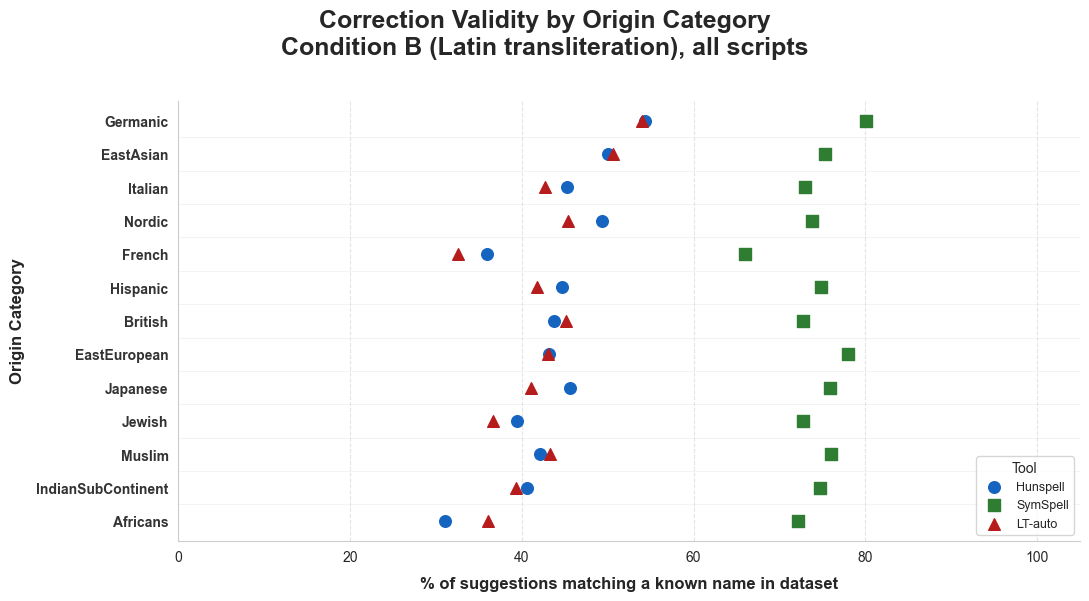

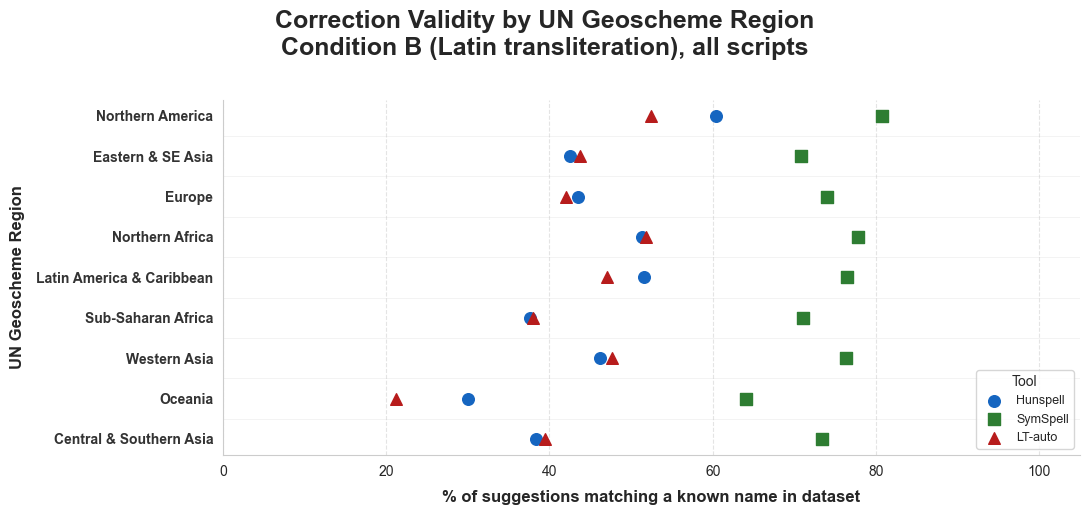

In [307]:
# Q3: Correction Validity
# % of suggestions that matched a known name in the dataset,
# by ethnicolr origin category and UN Geoscheme region (saved separately).
import matplotlib.pyplot as plt
import numpy as np

TOOL_PALETTE = {"Hunspell": "#1565c0", "SymSpell": "#2e7d32", "LT-auto": "#b71c1c"}
TOOL_MARKERS = {"Hunspell": "o", "SymSpell": "s", "LT-auto": "^"}
VALID_MAP = [
    ("Hunspell", "hunspell_latin_known", "hunspell_latin_correction", "hunspell_latin_correction_match"),
    ("SymSpell", "symspell_latin_known", "symspell_latin_correction", "symspell_latin_correction_match"),
    ("LT-auto",  "lt_auto_latin_known",  "lt_auto_latin_correction",  "lt_auto_latin_correction_match"),
]

def has_suggestion(row, corr_col):
    c = row[corr_col]
    return isinstance(c, str) and c.strip() != ""

def is_name_match(row, match_col):
    m = row[match_col]
    return isinstance(m, str) and m.strip() not in ("", "None")

eth_counts = df["eth_short"].value_counts()
valid_eth  = eth_counts[eth_counts >= 100].index
eth_sub    = df[(df["eth_short"].isin(valid_eth)) & (df["eth_short"] != "Unknown")].copy()

eth_valid = {}
for tool, known_col, corr_col, match_col in VALID_MAP:
    with_sugg = eth_sub[(eth_sub[known_col] == 0) &
                        eth_sub.apply(has_suggestion, axis=1, corr_col=corr_col)]
    eth_valid[tool] = (
        with_sugg.groupby("eth_short").apply(
            lambda g: g.apply(is_name_match, axis=1, match_col=match_col).mean() * 100
        ).rename(tool)
    )

eth_order = (
    eth_sub.groupby("eth_short")[[
        "hunspell_latin_known", "symspell_latin_known", "lt_auto_latin_known"
    ]].mean().mean(axis=1).sort_values().index.tolist()
)

lat_region = df.copy()
lat_region["region"] = lat_region["top_country"].map(REGION_MAP)
lat_region = lat_region[lat_region["region"].notna() & (lat_region["region"] != "Other")]

reg_valid = {}
for tool, known_col, corr_col, match_col in VALID_MAP:
    with_sugg = lat_region[(lat_region[known_col] == 0) &
                           lat_region.apply(has_suggestion, axis=1, corr_col=corr_col)]
    reg_valid[tool] = (
        with_sugg.groupby("region").apply(
            lambda g: g.apply(is_name_match, axis=1, match_col=match_col).mean() * 100
        ).rename(tool)
    )

reg_order = (
    lat_region.groupby("region")[[
        "hunspell_latin_known", "symspell_latin_known", "lt_auto_latin_known"
    ]].mean().mean(axis=1).sort_values().index.tolist()
)

def _valid_plot(valid_dict, order, ylabel, title, filename):
    y_pos = np.arange(len(order))
    fig, ax = plt.subplots(figsize=(11, max(5, len(order) * 0.45)), facecolor="white")
    ax.set_facecolor("white")
    for tool, series in valid_dict.items():
        vals = series.reindex(order).values
        ax.scatter(vals, y_pos, color=TOOL_PALETTE[tool],
                   marker=TOOL_MARKERS[tool], s=70, label=tool, zorder=3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(order, fontweight="bold", color="#333333")
    ax.set_xlabel("% of suggestions matching a known name in dataset",
                  fontweight="bold", fontsize=12, labelpad=8)
    ax.set_ylabel(ylabel, fontweight="bold", fontsize=12, labelpad=8)
    ax.set_xlim(0, 105)
    ax.grid(True, axis="x", linestyle="--", alpha=0.4, color="#bdbdbd")
    ax.grid(False, axis="y")
    for y in range(len(order) - 1):
        ax.axhline(y + 0.5, color="#bdbdbd", linewidth=0.4, alpha=0.3)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.legend(title="Tool", fontsize=9, loc="lower right", frameon=True)
    fig.suptitle(title, fontsize=18, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

_valid_plot(
    eth_valid, eth_order, "Origin Category",
    "Correction Validity by Origin Category\nCondition B (Latin transliteration), all scripts",
    "correction_validity_ethnicolr.png"
)
_valid_plot(
    reg_valid, reg_order, "UN Geoscheme Region",
    "Correction Validity by UN Geoscheme Region\nCondition B (Latin transliteration), all scripts",
    "correction_validity_un_region.png"
)

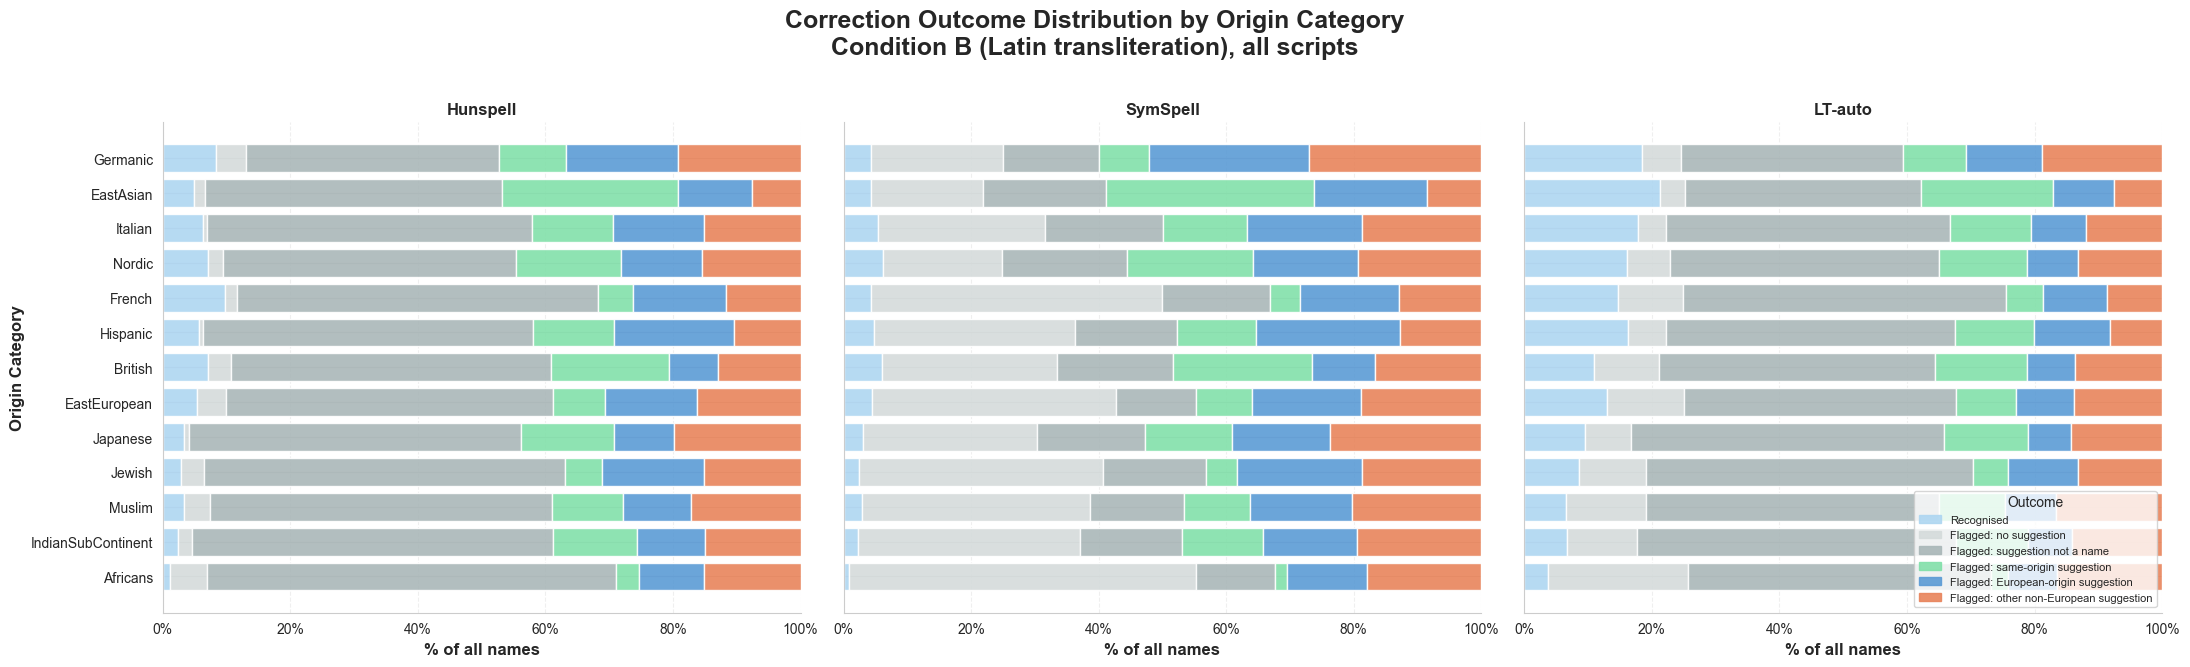

In [308]:
# Q3: Direction -- outcome stacked bar by ethnicolr origin (all names).
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

OUTCOME_COLS = [
    ("Hunspell", "hunspell_latin_known", "hunspell_latin_correction", "Hunspell_corr_eth"),
    ("SymSpell", "symspell_latin_known", "symspell_latin_correction", "SymSpell_corr_eth"),
    ("LT-auto",  "lt_auto_latin_known",  "lt_auto_latin_correction",  "LT-auto_corr_eth"),
]
OUTCOME_ORDER = [
    "Recognised",
    "Flagged: no suggestion",
    "Flagged: suggestion not a name",
    "Flagged: same-origin suggestion",
    "Flagged: European-origin suggestion",
    "Flagged: other non-European suggestion",
]
OUTCOME_COLOURS = {
    "Recognised":                            "#aed6f1",
    "Flagged: no suggestion":                "#D5DBDB",
    "Flagged: suggestion not a name":        "#AAB7B8",
    "Flagged: same-origin suggestion":       "#82e0aa",
    "Flagged: European-origin suggestion":   "#5B9BD5",
    "Flagged: other non-European suggestion":"#E8845B",
}

def classify_outcome(row, known_col, corr_col, corr_eth_col):
    if row[known_col] == 1:
        return "Recognised"
    corr = row[corr_col]
    if not isinstance(corr, str) or corr.strip() == "":
        return "Flagged: no suggestion"
    eth = row[corr_eth_col]
    if eth == "None" or pd.isna(eth):
        return "Flagged: suggestion not a name"
    if eth == row["eth_short"]:
        return "Flagged: same-origin suggestion"
    if eth in EUROPEAN_ETH:
        return "Flagged: European-origin suggestion"
    return "Flagged: other non-European suggestion"

eth_counts = df["eth_short"].value_counts()
valid_eth  = eth_counts[eth_counts >= 100].index
eth_sub    = df[(df["eth_short"].isin(valid_eth)) & (df["eth_short"] != "Unknown")].copy()

origin_order = (
    eth_sub.groupby("eth_short")[[
        "hunspell_latin_known", "symspell_latin_known", "lt_auto_latin_known"
    ]].mean().mean(axis=1).sort_values().index.tolist()
)

fig, axes = plt.subplots(1, 3, figsize=(22, max(6, len(origin_order) * 0.5)),
                         sharey=True, facecolor="white")

for ax, (tool, known_col, corr_col, corr_eth_col) in zip(axes, OUTCOME_COLS):
    sub = eth_sub.copy()
    sub["_outcome"] = sub.apply(
        classify_outcome, axis=1,
        known_col=known_col, corr_col=corr_col, corr_eth_col=corr_eth_col
    )
    pivot = sub.groupby(["eth_short", "_outcome"]).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    pivot_pct = pivot_pct.reindex(origin_order).dropna(how="all")

    left = np.zeros(len(pivot_pct))
    for outcome in OUTCOME_ORDER:
        if outcome not in pivot_pct.columns:
            continue
        vals = pivot_pct[outcome].fillna(0).values
        ax.barh(pivot_pct.index, vals, left=left,
                color=OUTCOME_COLOURS[outcome], alpha=0.9)
        left += vals

    ax.set_title(tool, fontsize=12, fontweight="bold")
    ax.set_xlabel("% of all names", fontweight="bold", fontsize=12)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_xlim(0, 100)
    ax.grid(axis="x", linestyle="--", alpha=0.3, zorder=0)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel("Origin Category", fontweight="bold", fontsize=12)
handles = [plt.Rectangle((0,0),1,1, color=OUTCOME_COLOURS[o], alpha=0.9) for o in OUTCOME_ORDER]
axes[-1].legend(handles, OUTCOME_ORDER, loc="lower right",
                fontsize=8, frameon=True, title="Outcome")
fig.suptitle(
    "Correction Outcome Distribution by Origin Category\nCondition B (Latin transliteration), all scripts",
    fontsize=18, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("correction_direction_ethnicolr.png", dpi=300, bbox_inches="tight")
plt.show()

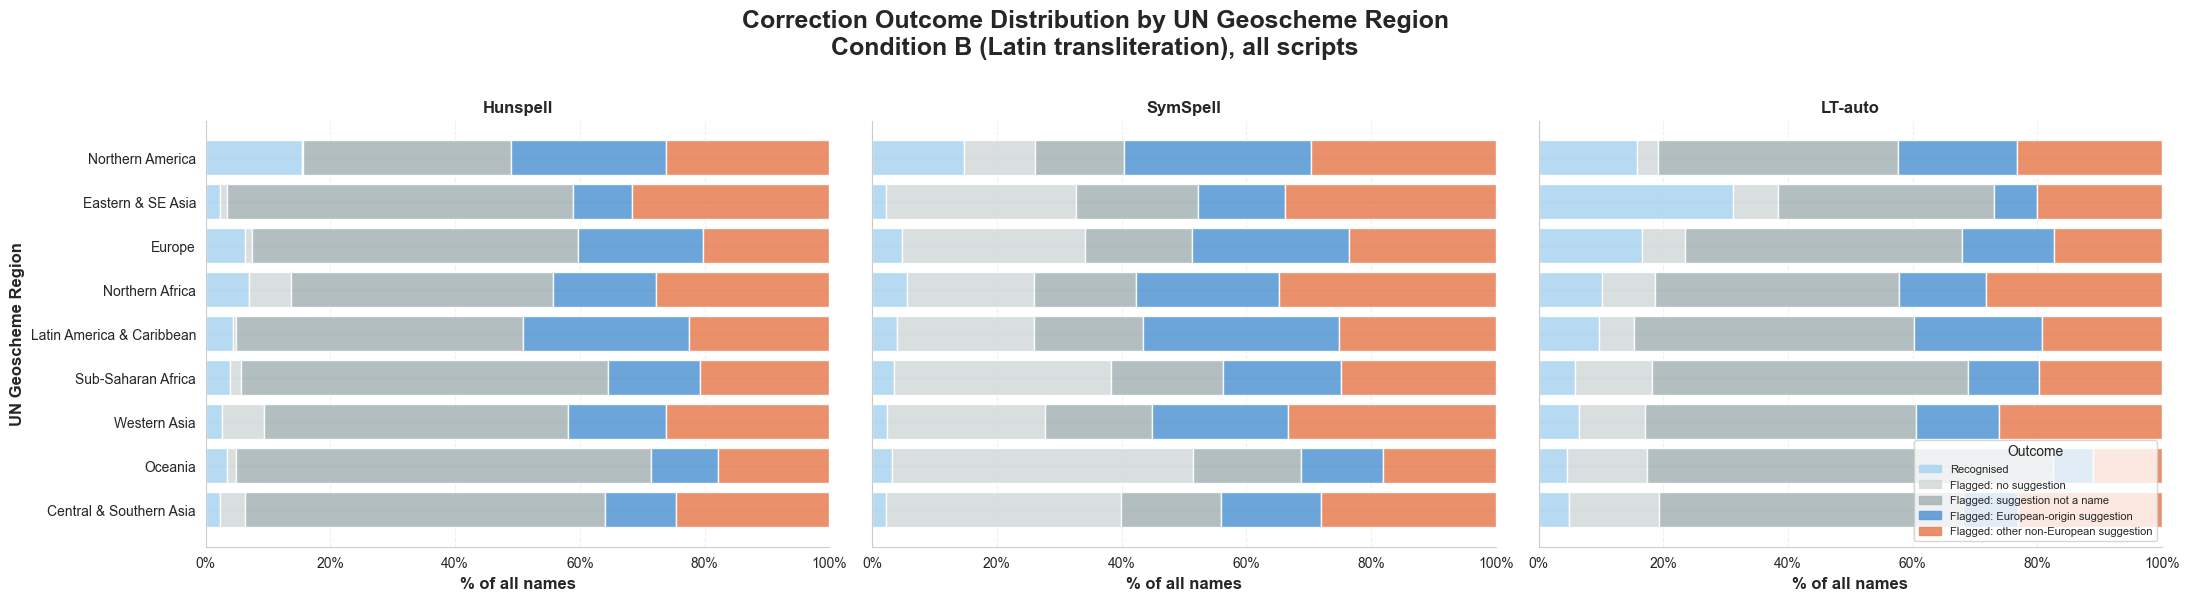

In [309]:
# Q3: Direction -- outcome stacked bar by UN Geoscheme region (all names).
# Reuses OUTCOME_ORDER, OUTCOME_COLOURS, classify_outcome from cell above.
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

OUTCOME_COLS_R = [
    ("Hunspell", "hunspell_latin_known", "hunspell_latin_correction", "Hunspell_corr_eth"),
    ("SymSpell", "symspell_latin_known", "symspell_latin_correction", "SymSpell_corr_eth"),
    ("LT-auto",  "lt_auto_latin_known",  "lt_auto_latin_correction",  "LT-auto_corr_eth"),
]

lat_region = df.copy()
lat_region["region"] = lat_region["top_country"].map(REGION_MAP)
lat_region = lat_region[lat_region["region"].notna() & (lat_region["region"] != "Other")]

region_order = (
    lat_region.groupby("region")[[
        "hunspell_latin_known", "symspell_latin_known", "lt_auto_latin_known"
    ]].mean().mean(axis=1).sort_values().index.tolist()
)

region_outcome_order = [o for o in OUTCOME_ORDER if o != "Flagged: same-origin suggestion"]

fig, axes = plt.subplots(1, 3, figsize=(22, max(5, len(region_order) * 0.65)),
                         sharey=True, facecolor="white")

for ax, (tool, known_col, corr_col, corr_eth_col) in zip(axes, OUTCOME_COLS_R):
    sub = lat_region.copy()

    def _classify(row):
        if row[known_col] == 1:
            return "Recognised"
        corr = row[corr_col]
        if not isinstance(corr, str) or corr.strip() == "":
            return "Flagged: no suggestion"
        eth = row[corr_eth_col]
        if eth == "None" or pd.isna(eth):
            return "Flagged: suggestion not a name"
        if eth in EUROPEAN_ETH:
            return "Flagged: European-origin suggestion"
        return "Flagged: other non-European suggestion"

    sub["_outcome"] = sub.apply(_classify, axis=1)
    pivot = sub.groupby(["region", "_outcome"]).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    pivot_pct = pivot_pct.reindex(region_order).dropna(how="all")

    left = np.zeros(len(pivot_pct))
    for outcome in region_outcome_order:
        if outcome not in pivot_pct.columns:
            continue
        vals = pivot_pct[outcome].fillna(0).values
        ax.barh(pivot_pct.index, vals, left=left,
                color=OUTCOME_COLOURS[outcome], alpha=0.9)
        left += vals

    ax.set_title(tool, fontsize=12, fontweight="bold")
    ax.set_xlabel("% of all names", fontweight="bold", fontsize=12)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_xlim(0, 100)
    ax.grid(axis="x", linestyle="--", alpha=0.3, zorder=0)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel("UN Geoscheme Region", fontweight="bold", fontsize=12)
handles = [plt.Rectangle((0,0),1,1, color=OUTCOME_COLOURS[o], alpha=0.9)
           for o in region_outcome_order]
axes[-1].legend(handles, region_outcome_order, loc="lower right",
                fontsize=8, frameon=True, title="Outcome")
fig.suptitle(
    "Correction Outcome Distribution by UN Geoscheme Region\nCondition B (Latin transliteration), all scripts",
    fontsize=18, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("correction_direction_un_region.png", dpi=300, bbox_inches="tight")
plt.show()

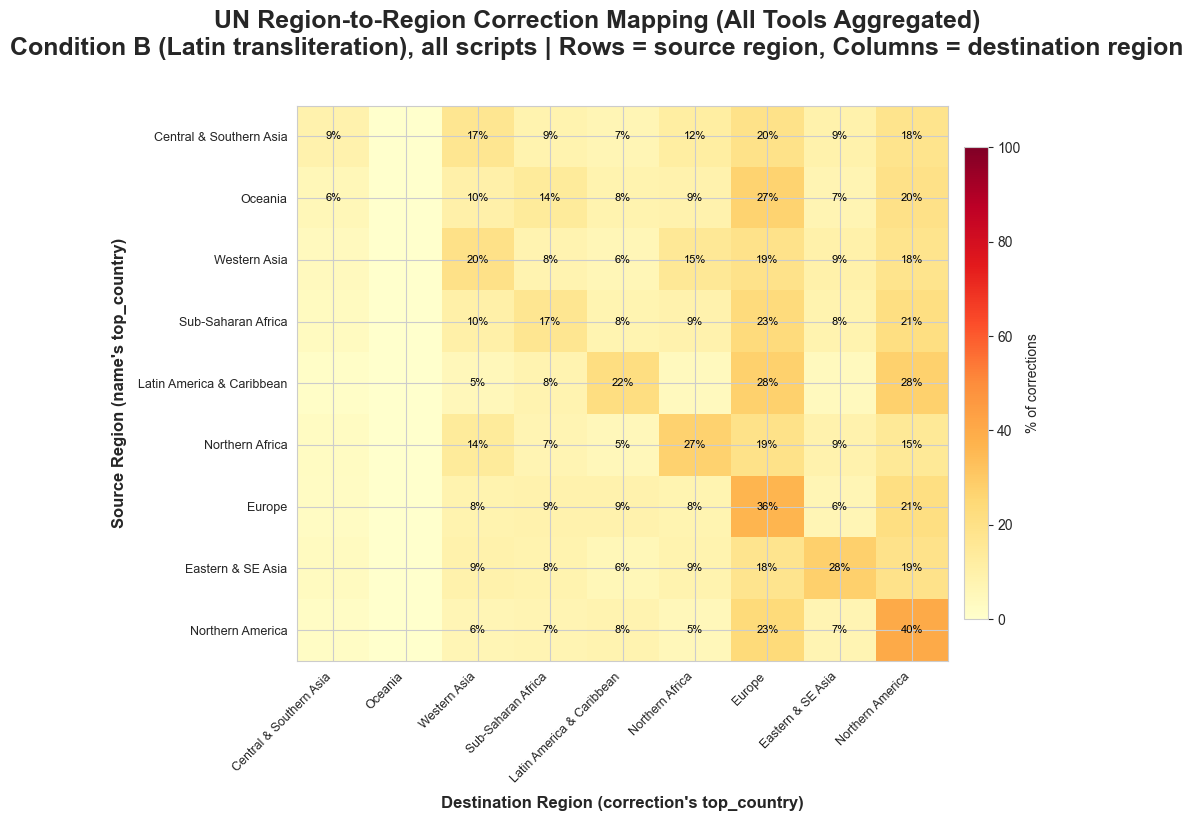

In [311]:
# Q3: Region-to-region correction mapping heatmap (aggregated across all tools)
# For names from each UN Geoscheme source region, what proportion of corrections
# (pooled across Hunspell, SymSpell, LT-auto) point to names whose top_country
# falls in each destination region?
import matplotlib.pyplot as plt
import numpy as np

MATCH_COLS = [
    ("hunspell_latin_known",  "hunspell_latin_correction_match"),
    ("symspell_latin_known",  "symspell_latin_correction_match"),
    ("lt_auto_latin_known",   "lt_auto_latin_correction_match"),
]

def extract_top_country(val):
    if not isinstance(val, str) or val.strip() in ("", "None"):
        return None
    try:
        return json.loads(val).get("top_country")
    except Exception:
        return None

base = df.copy()
base["source_region"] = base["top_country"].map(REGION_MAP)
base = base[base["source_region"].notna() & (base["source_region"] != "Other")]

region_order = (
    base.groupby("source_region")[[
        "hunspell_latin_known", "symspell_latin_known", "lt_auto_latin_known"
    ]].mean().mean(axis=1).sort_values().index.tolist()
)

# Aggregate counts across all three tools
from collections import defaultdict
agg_counts = defaultdict(lambda: defaultdict(int))

for known_col, match_col in MATCH_COLS:
    flagged = base[base[known_col] == 0].copy()
    flagged["dest_country"] = flagged[match_col].apply(extract_top_country)
    flagged["dest_region"]  = flagged["dest_country"].map(REGION_MAP)
    has_dest = flagged[flagged["dest_region"].notna() & (flagged["dest_region"] != "Other")]
    for src, dst in zip(has_dest["source_region"], has_dest["dest_region"]):
        agg_counts[src][dst] += 1

# Build matrix
pivot = pd.DataFrame(agg_counts).T.reindex(
    index=region_order, columns=region_order, fill_value=0
).fillna(0)
row_sums = pivot.sum(axis=1).replace(0, np.nan)
pct = pivot.div(row_sums, axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 8), facecolor="white")
ax.set_facecolor("white")

im = ax.imshow(pct.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=100)

ax.set_xticks(range(len(region_order)))
ax.set_xticklabels(region_order, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(region_order)))
ax.set_yticklabels(region_order, fontsize=9)
ax.set_xlabel("Destination Region (correction's top_country)",
              fontweight="bold", fontsize=12, labelpad=8)
ax.set_ylabel("Source Region (name's top_country)",
              fontweight="bold", fontsize=12, labelpad=8)

for r in range(len(region_order)):
    for c in range(len(region_order)):
        val = pct.values[r, c]
        if not np.isnan(val) and val >= 5:
            ax.text(c, r, f"{val:.0f}%", ha="center", va="center",
                    fontsize=8, color="black" if val < 60 else "white")

fig.colorbar(im, ax=ax, label="% of corrections", shrink=0.85, pad=0.02)
fig.suptitle(
    "UN Region-to-Region Correction Mapping (All Tools Aggregated)\n"
    "Condition B (Latin transliteration), all scripts | "
    "Rows = source region, Columns = destination region",
    fontsize=18, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("correction_region_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Summary

| Claim | Evidence | Strength |
|-------|----------|----------|
| Recognition gap exists (Q1) | Wilson CIs + chi-sq + Cohen's h | Very strong |
| Gap is consistent across tools (Q1) | All three tools show same direction | Strong |
| Gap is partly script-level (Q2) | McNemar (LT-auto A vs B) + logreg script model | Strong |
| Gap has lexical component (Q2) | Logreg origin model, Latin-script only | Moderate |
| Phonetic conformity drives recognition (Q2) | country_lang_comp + primary lang analysis | Moderate |
| Corrections skew European-origin (Q3) | Direction analysis | Exploratory |

**country_lang_comp** is a useful additional lens: names from countries where the
detected language doesn't match the official language are recognised less even within
Latin script -- the tools reward phonetic conformity to European orthographic norms.
